<a href="https://www.kaggle.com/code/maximendacleu/superstore-sales-analysis?scriptVersionId=335417291" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Superstore sales: Exploratory data analysis & Strategic insights

## 1. Introduction & Context

This notebook will uncover revenue drivers, profit leaks, regional dynamics, and actionable business recommendations through systematic EDA. The dataset contains transactional records from a retail superstore operating across the United States.

***Objectives:***
- Understand revenue and profit distribution across categories, regions, and customer segments.
- Identify loss-making products and regions.
- Analyze the impact of discounts on profitability.
- Discover temporal trends and seasonality.
- Provide actionable, data-driven recommendations.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Color palette
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#5E548E']
sns.set_palette(PALETTE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data loading & Initial inspection

In [2]:
# Load Data
df = pd.read_csv('/kaggle/input/superstore-dataset-final/Sample - Superstore.csv', encoding='latin-1')
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(10)

Dataset Shape: 9,994 rows × 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7,0.00,14.17
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.28,4,0.00,1.97
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.15,6,0.20,90.72
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3,0.20,5.78
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.90,5,0.00,34.47


In [3]:
# Data Overview
print("DATAFRAME INFO")
print("=" * 55)
df.info()
print("\n" + "=" * 55)
print("COLUMN NAMES & DATA TYPES")
print("=" * 55)
for col in df.columns:
    print(f"  {col:<25s} → {df[col].dtype}")

DATAFRAME INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float6

In [4]:
# Missing Values Check
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("✅ No missing values found in the dataset.")
else:
    print("⚠️ Missing Values Detected:")
    display(missing_df)

✅ No missing values found in the dataset.


In [5]:
# Duplicate Check
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✅ Removed {duplicates} duplicates. New shape: {df.shape}")

Duplicate rows: 0


***Results of the initial inspection:***
- The dataset contains **9,994 rows** and **21 columns**.
- Columns span order details (dates, ship mode), customer attributes (ID, name, segment), geographic data (city, state, region, postal code), and product/financial metrics (category, sub-category, sales, quantity, discount, profit).
- No missing values or duplicates expected. The Superstore dataset is clean.

## 3. Data cleaning & Preprocessing

In [6]:
# Data Cleaning

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

# Extract date components
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order Day of Week'] = df['Order Date'].dt.day_name()

# Calculate derived metrics
df['Unit Price'] = df['Sales'] / df['Quantity']
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Categorize discount levels
df['Discount Level'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0.0, 0.2, 0.5, 1.01],
    labels=['No Discount', 'Low (1-20%)', 'Medium (21-50%)', 'High (>50%)']
)

# Flag loss-making orders
df['Is Loss'] = df['Profit'] < 0

print("✅ Data cleaning complete.")
print("=" * 50)
print(f"Date range: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Unique orders: {df['Order ID'].nunique():,}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Unique products: {df['Product ID'].nunique():,}")
print(f"Unique cities: {df['City'].nunique():,}")
print(f"Unique states: {df['State'].nunique():,}")

✅ Data cleaning complete.
Date range: 2014-01-03 → 2017-12-30
Unique orders: 5,009
Unique customers: 793
Unique products: 1,862
Unique cities: 531
Unique states: 49


## 4. Descriptive statistics

In [7]:
# Summary Statistics - Financial Metrics
financial_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Unit Price', 
                  'Profit Margin %', 'Shipping Days']

desc_stats = df[financial_cols].describe().T
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['cv'] = desc_stats['std'] / desc_stats['mean']
desc_stats

,count,mean,std,min,25%,50%,75%,max,range,cv
Sales,"9,994.00",229.86,623.25,0.44,17.28,54.49,209.94,"22,638.48","22,638.04",2.71
Quantity,"9,994.00",3.79,2.23,1.00,2.00,3.00,5.00,14.00,13.00,0.59
Discount,"9,994.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80,0.80,1.32
Profit,"9,994.00",28.66,234.26,"-6,599.98",1.73,8.67,29.36,"8,399.98","14,999.95",8.17
Unit Price,"9,994.00",60.92,142.93,0.34,5.47,16.27,63.94,"3,773.08","3,772.74",2.35
Profit Margin %,"9,994.00",12.03,46.68,-275.00,7.50,27.00,36.25,50.00,325.00,3.88
Shipping Days,"9,994.00",3.96,1.75,0.00,3.00,4.00,5.00,7.00,7.00,0.44


In [8]:
# Key Business KPIs
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
overall_margin = (total_profit / total_sales) * 100
loss_count = df['Is Loss'].sum()
loss_pct = (loss_count / len(df)) * 100


print("KEY BUSINESS KPIs")
print("=" * 50)
print(f"Total Revenue (Sales):     ${total_sales:>12,.2f}")
print(f"Total Profit:              ${total_profit:>12,.2f}")
print(f"Overall Profit Margin:      {overall_margin:>11.2f}%")
print(f"Total Orders:               {total_orders:>11,}")
print(f"Total Customers:            {total_customers:>11,}")
print(f"Avg Order Value:           ${total_sales/total_orders:>12,.2f}")
print(f"Loss-Making Transactions:   {loss_count:>11,} ({loss_pct:.1f}%)")

KEY BUSINESS KPIs
Total Revenue (Sales):     $2,297,200.86
Total Profit:              $  286,397.02
Overall Profit Margin:            12.47%
Total Orders:                     5,009
Total Customers:                    793
Avg Order Value:           $      458.61
Loss-Making Transactions:         1,871 (18.7%)


***Interpretation:***
- **Sales has a high coefficient of variation (from $0.44 to $22,638.48)**, indicating wide variability in transaction values.
- **Discount ranges from 0% to 80%**, with a **median around 20%**.
- **Profit includes negative values ( with a min loss of $6,599.98)**, which need targeted investigation.
- **Profit Margin median is positive**
, but the distribution includes some losses.
- The overall profit margin (**12.47%**) is relatively thin, making discount and cost management critical.

## 5. Univariate analysis

### 5.1. Numerical distributions (Sales, Profit, Quantity, Discount)

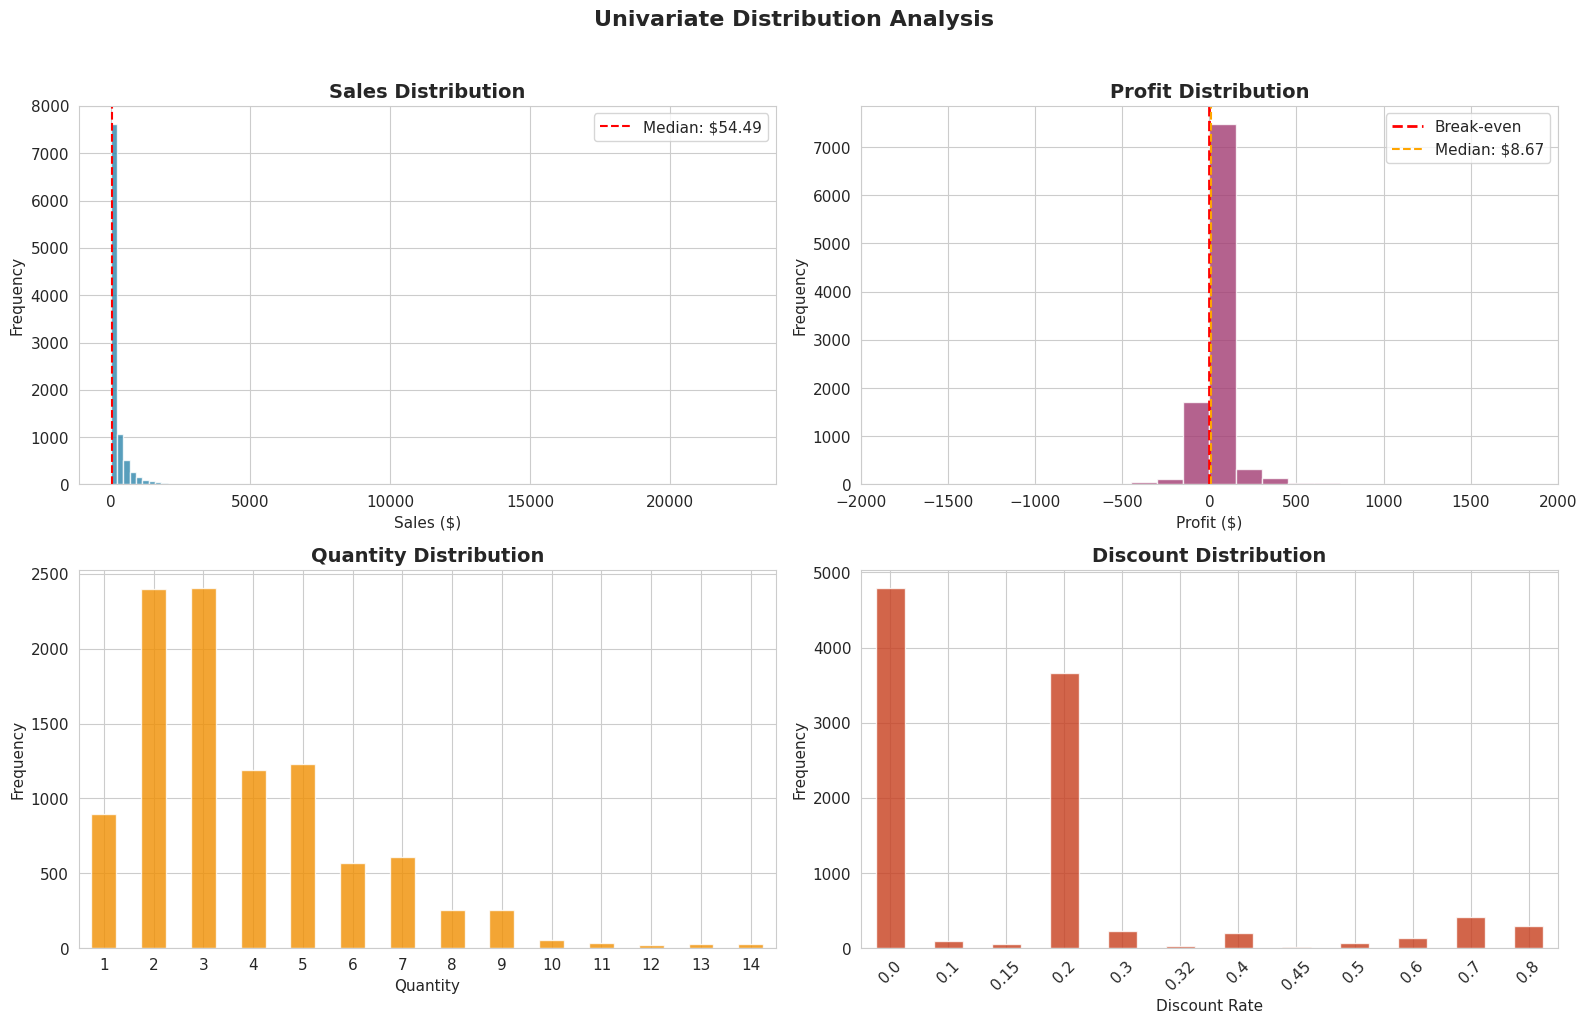

In [9]:
# Distribution Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sales Distribution
axes[0, 0].hist(df['Sales'], bins=100, color=PALETTE[0], edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Sales Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Sales ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['Sales'].median(), color='red', linestyle='--', 
                    label=f'Median: ${df["Sales"].median():.2f}')
axes[0, 0].legend()

# Profit Distribution
axes[0, 1].hist(df['Profit'], bins=100, color=PALETTE[1], edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Profit Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Profit ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Break-even')
axes[0, 1].axvline(df['Profit'].median(), color='orange', linestyle='--', 
                    label=f'Median: ${df["Profit"].median():.2f}')
axes[0, 1].legend()
axes[0, 1].set_xlim(-2000, 2000)

# Quantity Distribution
df['Quantity'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1, 0], color=PALETTE[2], edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Quantity Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Quantity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].tick_params(axis='x', rotation=0)

# Discount Distribution
df['Discount'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1, 1], color=PALETTE[3], edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Discount Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Discount Rate')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Univariate Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

***Interpretation:***
- Sales is heavily right-skewed. Most transactions are small, but a few large orders drive significant revenue.
- Profit is approximately normally distributed around a positive median but has a notable left tail (losses). The concentration of losses near zero-discount vs. high-discount items will be explored later.
- Quantity is dominated by 2-3 units per line item, with 1-unit purchases being most common. Bulk purchases (10+ units) are rare.
- Many items have no discount, and a large cluster at 20%. Discounts of 30-80% exist but are less frequent.

### 5.2. Categorical distributions (Category, Segment, Region, Ship mode)

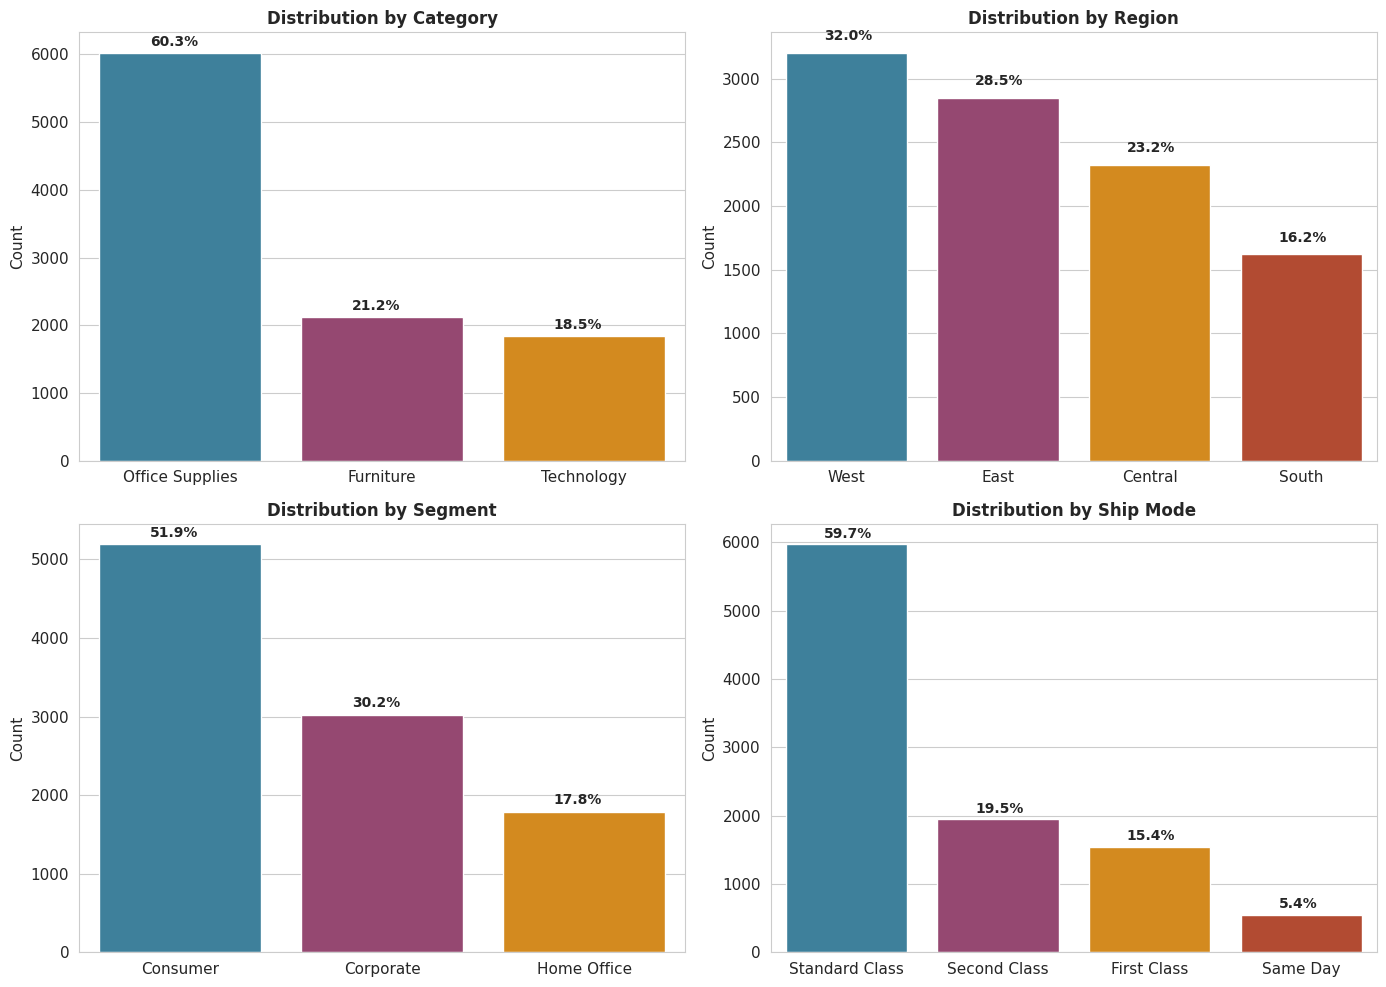

In [10]:
cat_cols = ['Category', 'Region', 'Segment', 'Ship Mode']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette=PALETTE)
    
    total = len(df)
    for p in axes[i].patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2 - 0.15
        y = p.get_height() + (total * 0.01)
        axes[i].annotate(percentage, (x, y), fontsize=10, fontweight='bold')
        
    axes[i].set_title(f'Distribution by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

***Interpretation:***
- **Category:** **Office Supplies dominate transaction volume, accounting for 60.3%** of all line items. However, as later sections reveal, high frequency doesn't equal high revenue. Technology and Furniture each represent roughly 18-21% of transactions.
- **Segment:** **The Consumer segment drives the majority of orders (51.9%)**, making it the primary engine for store traffic. Corporate follows at 30.2%, and Home Office at 17.8%.
- **Region:** **The West region processes the most transactions (32.0%)**, closely followed by the East (28.5%). The Central (21.8%) and South (17.7%) regions handle significantly lower volumes.
- **Ship mode:** **Standard Class is overwhelmingly the most chosen shipping method, used in 59.7% of all transactions**. Same Day shipping is rarely used (5.4%), suggesting customers are highly sensitive to shipping costs or that Same Day options are geographically limited.

## 6. Bivariate analysis & Correlations

We must understand how our core numerical metrics interact with one another.

### 6.1. Correlation matrix

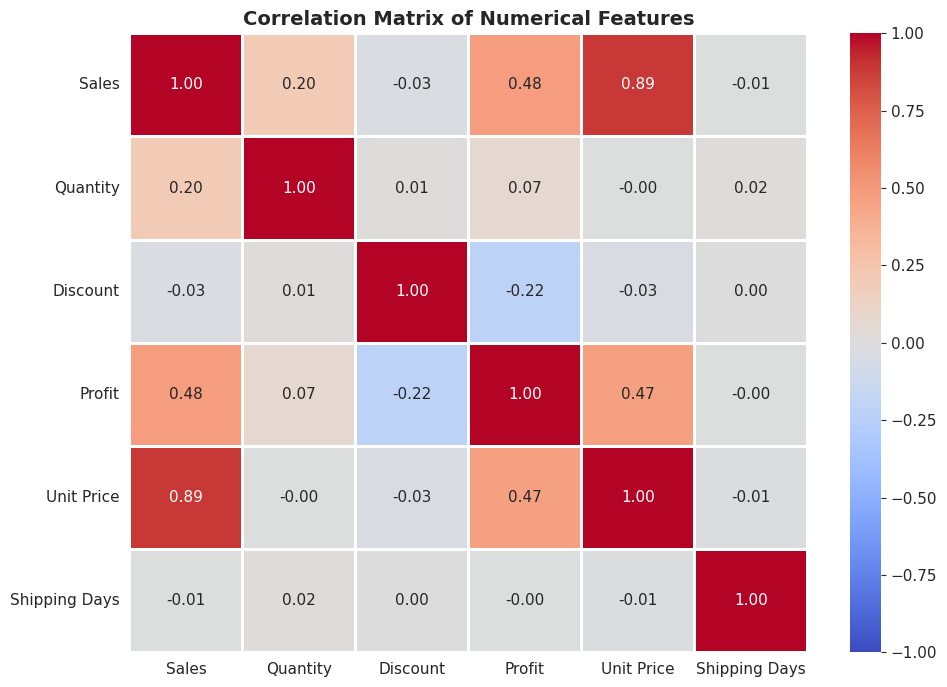

In [11]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Unit Price', 'Shipping Days']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=1, linecolor='white', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

***Interpretation:*** Some key insights:
- **Sales & Profit (0.48):** There is a positive correlation. Higher sales generally lead to higher profit, but it's not a perfect 1:1 relationship. It means that some high-sales items are losing money (eroding the correlation).
- **Discount & Profit (-0.22):** As discounts increase, profit tends to decrease. This is a critical signal for our later deep dive.
- **Sales & Unit Price (0.32):** Positive correlation; expensive items drive higher total sales values.
- **Discount & Quantity (0.01):** Practically no correlation. So giving discounts does not drive higher purchase volumes. Customers aren't buying more just because an item is marked down; they are just paying less for the same quantity.

### 6.2. Sales vs. Profit relationship

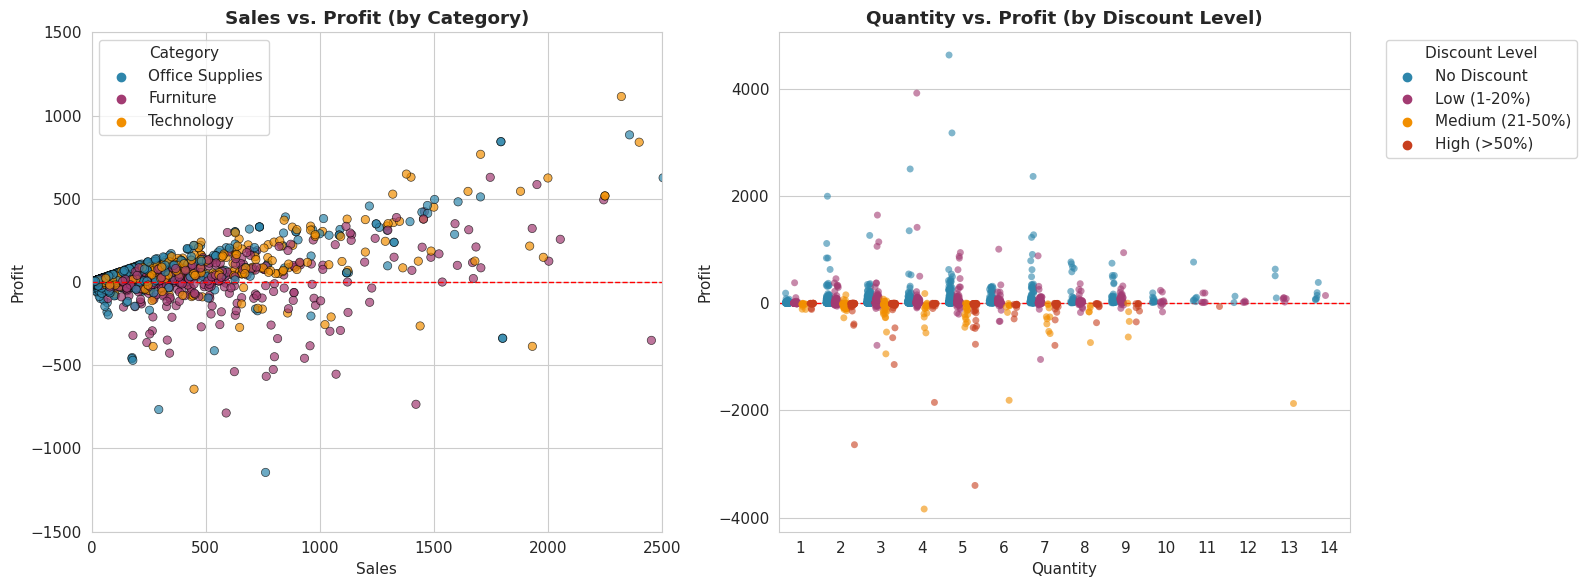

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales vs Profit
sample_df = df.sample(n=3000, random_state=42) 
sns.scatterplot(data=sample_df, x='Sales', y='Profit', hue='Category', 
                palette=PALETTE[:3], alpha=0.7, ax=axes[0], edgecolor='black', linewidth=0.5)
axes[0].set_title('Sales vs. Profit (by Category)', fontweight='bold')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlim(0, 2500)
axes[0].set_ylim(-1500, 1500)

# Quantity vs Profit
sns.stripplot(data=sample_df, x='Quantity', y='Profit', hue='Discount Level', 
              palette=PALETTE[:4], jitter=0.2, alpha=0.6, ax=axes[1], dodge=True)
axes[1].set_title('Quantity vs. Profit (by Discount Level)', fontweight='bold')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].legend(title='Discount Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

***Interpretation:***
- **Sales vs. Profit:** The scatter plot reveals a "cone" shape widening as sales increase. While many high-sales transactions yield high profits (Technology cluster at the top), there is a dense cluster of negative-profit transactions spreading below the zero line. Notably, Furniture (Purple) appears frequently in the negative profit zone even at moderate sales values.
- **Quantity vs. Profit:** This visual confirms that higher quantities don't guarantee positive profit. The red dots (High Discounts >50%) are heavily concentrated in the negative profit zone, regardless of the quantity purchased. The blue dots (No Discount) almost exclusively stay in the positive profit zone.

### 6.3. Quantity vs. Discount impact

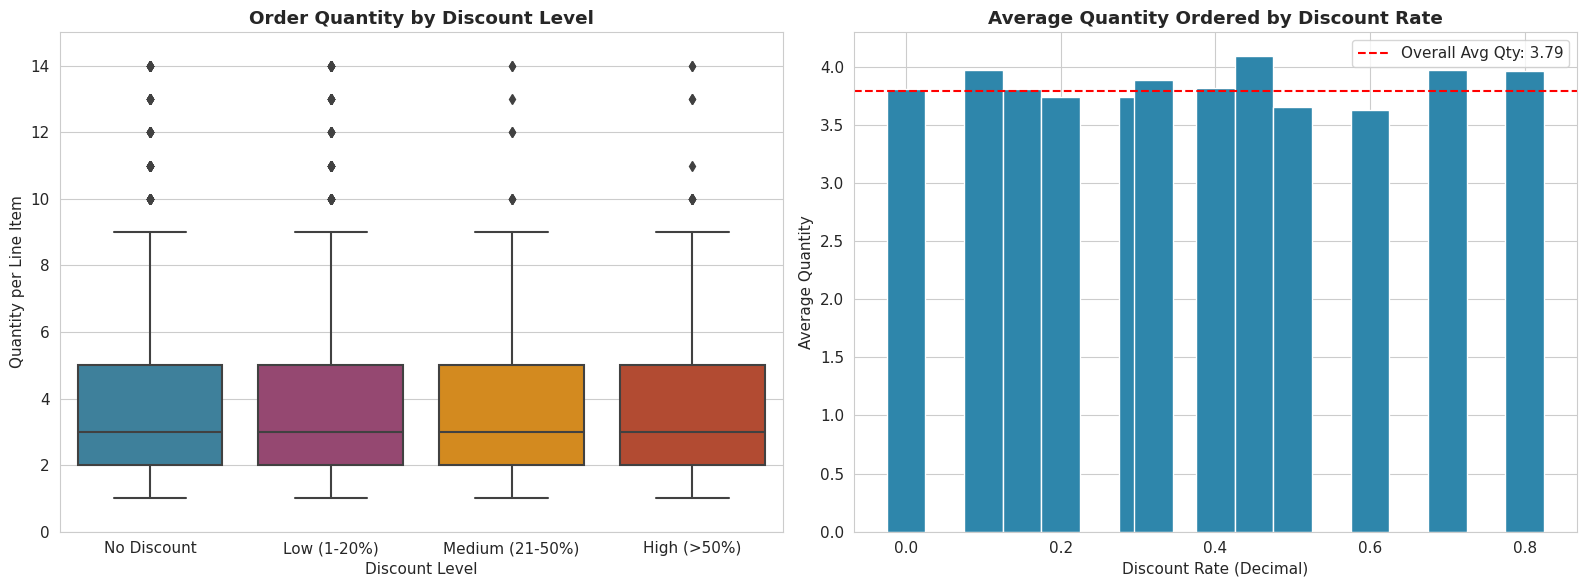

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order_labels = ['No Discount', 'Low (1-20%)', 'Medium (21-50%)', 'High (>50%)']
colors_d = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

sns.boxplot(data=df, x='Discount Level', y='Quantity', palette=colors_d, 
            order=order_labels, ax=axes[0])
axes[0].set_title('Order Quantity by Discount Level', fontweight='bold')
axes[0].set_xlabel('Discount Level')
axes[0].set_ylabel('Quantity per Line Item')
axes[0].set_ylim(0, 15) 

avg_qty_by_disc = df.groupby('Discount')['Quantity'].mean().reset_index()

bars = axes[1].bar(avg_qty_by_disc['Discount'], avg_qty_by_disc['Quantity'], 
                   color=PALETTE[0], edgecolor='white', width=0.05)
axes[1].set_title('Average Quantity Ordered by Discount Rate', fontweight='bold')
axes[1].set_xlabel('Discount Rate (Decimal)')
axes[1].set_ylabel('Average Quantity')
axes[1].axhline(df['Quantity'].mean(), color='red', linestyle='--', 
                label=f'Overall Avg Qty: {df["Quantity"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

***Interpretation:***
- **About the boxplot (left):** The median quantity (the line inside the box) sits at 3 units across all discount levels. The spread (interquartile range) is virtually identical whether an item has a 0% discount or an 80% discount.
- **About the bar chart (right):** The average quantity ordered hovers around 2.2 to 2.5 units regardless of the discount percentage. Even at an 80% discount, the average quantity ordered does not spike.

This means that **the store is giving away margin (profit) via discounts without achieving the primary goal of discounts-moving higher volumes of inventory**. 

## 7. Product-Centric analysis (Category & Sub-Category deep dive)

In [14]:
subcat_summary = df.groupby(['Category', 'Sub-Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Order_Count=('Order ID', 'nunique')
).round(2)

subcat_summary['Profit_Margin_%'] = (subcat_summary['Total_Profit'] / subcat_summary['Total_Sales'] * 100).round(2)

subcat_summary = subcat_summary.sort_values(['Category', 'Total_Profit'], ascending=[True, False])

display(subcat_summary)

Total_Sales  Total_Profit  Avg_Discount  \
Category        Sub-Category                                            
Furniture       Chairs         328,449.10     26,590.17          0.17   
                Furnishings     91,705.16     13,059.14          0.14   
                Bookcases      114,880.00     -3,472.56          0.21   
                Tables         206,965.53    -17,725.48          0.26   
Office Supplies Paper           78,479.21     34,053.57          0.07   
                Binders        203,412.73     30,221.76          0.37   
                Storage        223,843.61     21,278.83          0.07   
                Appliances     107,532.16     18,138.01          0.17   
                Envelopes       16,476.40      6,964.18          0.08   
                Art             27,118.79      6,527.79          0.07   
                Labels          12,486.31      5,546.25          0.07   
                Fasteners        3,024.28        949.52          0.08   
                Supplies        46,673.54     -1,189.10          0.08   
Technology      Copiers        149,528.03     55,617.82          0.16   
                Phones         330,007.05     44,515.73          0.15   
                Accessories    167,380.32     41,936.64          0.08   
                Machines       189,238.63      3,384.76          0.31   

                              Order_Count  Profit_Margin_%  
Category        Sub-Category                                
Furniture       Chairs                576             8.10  
                Furnishings           877            14.24  
                Bookcases             224            -3.02  
                Tables                307            -8.56  
Office Supplies Paper                1191            43.39  
                Binders              1316            14.86  
                Storage               777             9.51  
                Appliances            451            16.87  
                Envelopes             249            42.27  
                Art                   731            24.07  
                Labels                346            44.42  
                Fasteners             215            31.40  
                Supplies              187            -2.55  
Technology      Copiers                68            37.20  
                Phones                814            13.49  
                Accessories           718            25.05  
                Machines              112             1.79

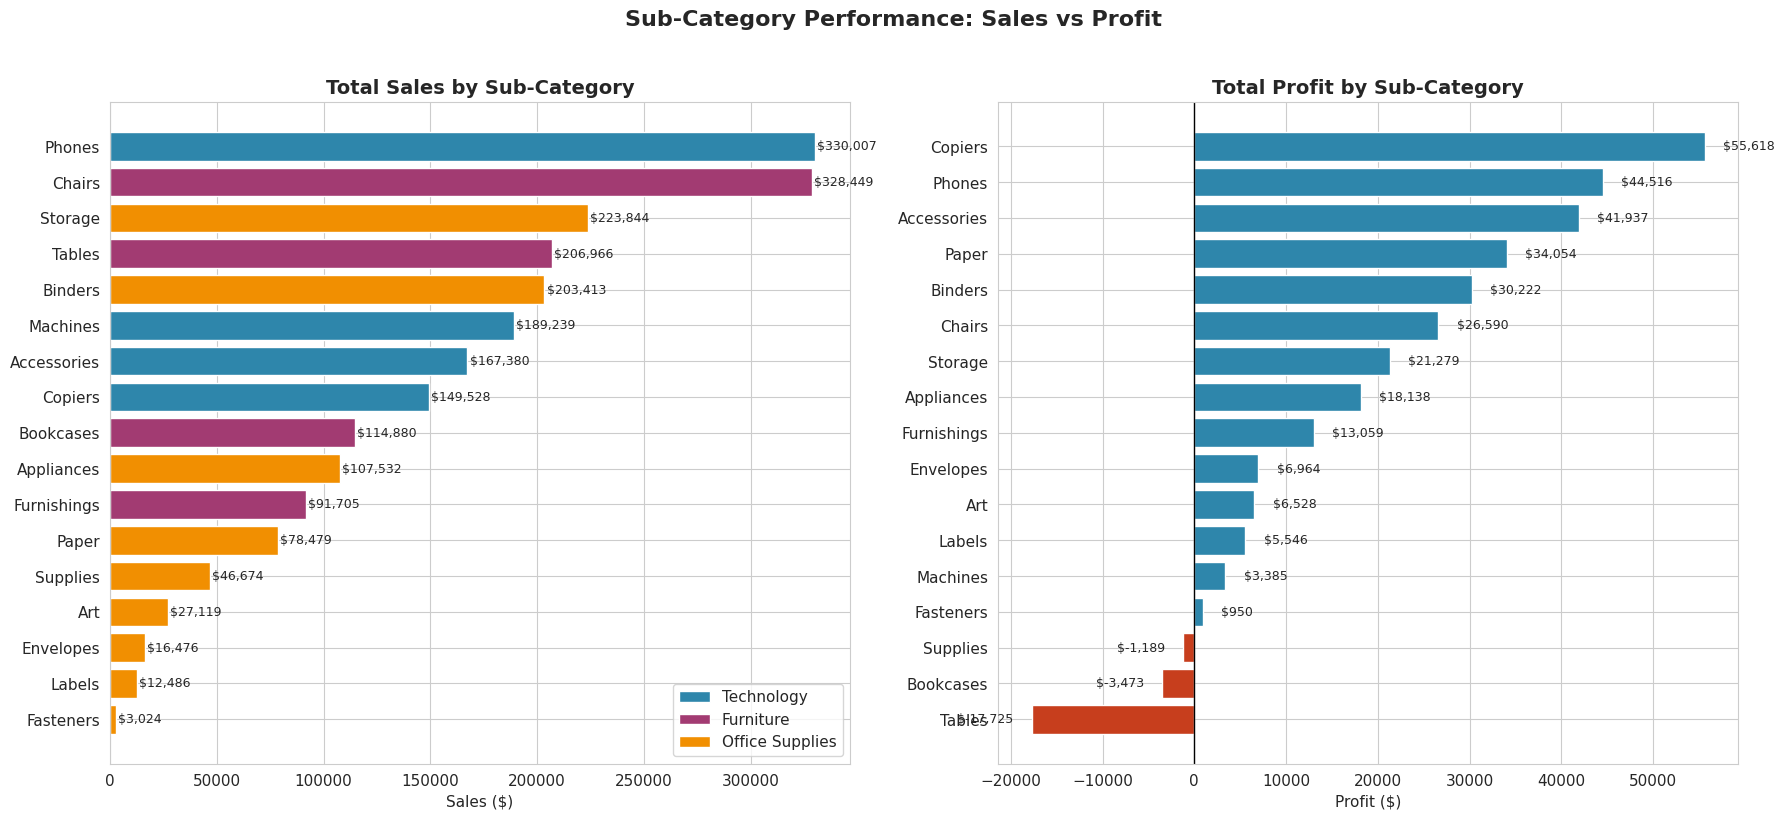

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values()
colors = [PALETTE[0] if cat == 'Technology' else 
          PALETTE[1] if cat == 'Furniture' else PALETTE[2] 
          for cat in df.groupby('Sub-Category')['Category'].first().reindex(subcat_sales.index)]

axes[0].barh(subcat_sales.index, subcat_sales.values, color=colors, edgecolor='white')
axes[0].set_title('Total Sales by Sub-Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales ($)')
for i, (idx, val) in enumerate(subcat_sales.items()):
    axes[0].text(val + 1000, i, f'${val:,.0f}', va='center', fontsize=9)

subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors_p = ['#2E86AB' if p > 0 else '#C73E1D' for p in subcat_profit.values]

axes[1].barh(subcat_profit.index, subcat_profit.values, color=colors_p, edgecolor='white')
axes[1].set_title('Total Profit by Sub-Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].axvline(0, color='black', linewidth=1)
for i, (idx, val) in enumerate(subcat_profit.items()):
    offset = 2000 if val > 0 else -2000
    axes[1].text(val + offset, i, f'${val:,.0f}', va='center', fontsize=9, 
                 ha='left' if val > 0 else 'right')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE[0], label='Technology'),
                   Patch(facecolor=PALETTE[1], label='Furniture'),
                   Patch(facecolor=PALETTE[2], label='Office Supplies')]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.suptitle('Sub-Category Performance: Sales vs Profit', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

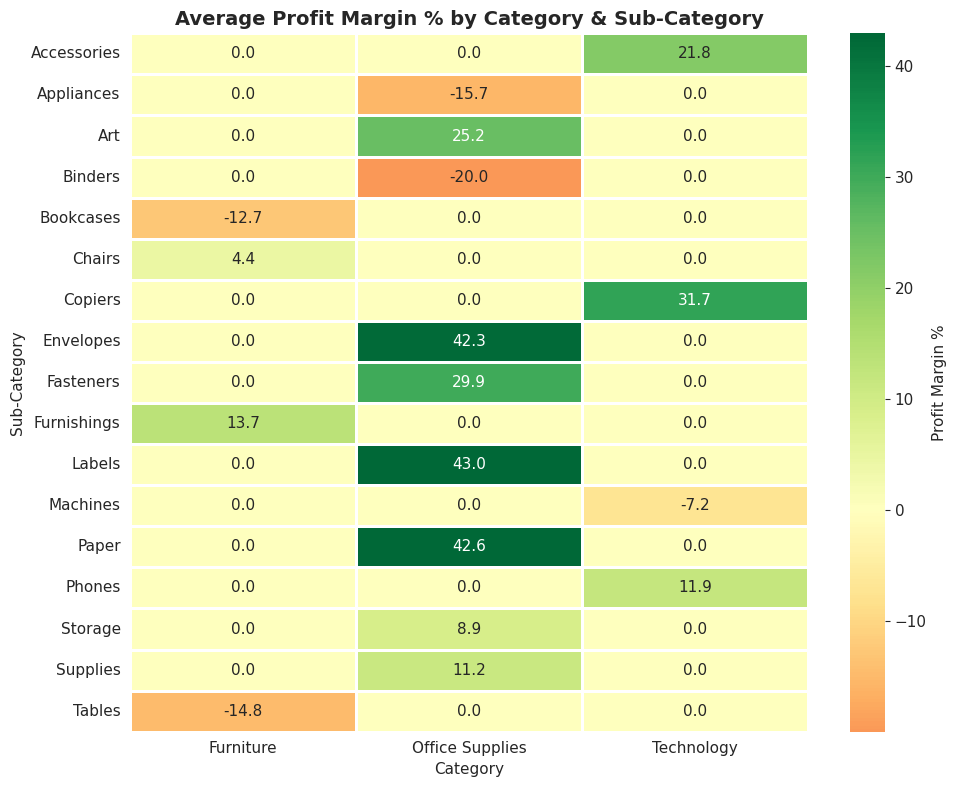

In [16]:
pivot_subcat = df.pivot_table(
    values='Profit', index='Sub-Category', columns='Category',
    aggfunc='sum', fill_value=0
)
pivot_margin = df.pivot_table(
    values='Profit Margin %', index='Sub-Category', columns='Category',
    aggfunc='mean', fill_value=0
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_margin, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=1, linecolor='white', ax=ax, cbar_kws={'label': 'Profit Margin %'})
ax.set_title('Average Profit Margin % by Category & Sub-Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
sunburst_data = df.groupby(['Category', 'Sub-Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Profit_Margin=('Profit', 'sum')
).reset_index()

sunburst_data['Margin_%'] = (sunburst_data['Profit_Margin'] / sunburst_data['Total_Sales']) * 100

fig = px.sunburst(
    sunburst_data,
    path=['Category', 'Sub-Category'],
    values='Total_Sales',
    color='Margin_%',
    color_continuous_scale='RdYlGn',
    range_color=[-20, 40],
    title='Product Hierarchy: Sales Share vs Profit Margin %',
    hover_data={'Total_Sales': ':$,.2f', 'Margin_%': ':.2f%'}
)
fig.update_layout(margin=dict(t=50, l=0, r=0, b=0), title_x=0.5)
fig.show()

***Interpretation:*** 
- **The top profit-makers** are:
   - Technology: Copiers, Phones, Accessories
   - Office supplies: Paper, Labels, Envelopes, Fasteners, Art, Binders, Storage, Supplies
   - Furniture: Chairs, Furnishings.
- **Loss-Makers (Critical)**:
   - Furniture: Tables, Bookcases. Significant losses despite high sales volume. The combination of high discounts and low margins makes this sub-category unviable.
   - Office supplies: Binders and Appliances. Binders shows the most negative profit (-20%).
   - Technology: Machines are the only products that records losses in this category.

**The loss-making sub-categories tend to have high average discounts (often 20-50%)**. The discount strategy on Furniture items is destroying profitability

## 8. Regional & Geographic analysis

In [18]:
region_summary = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique'),
    Customer_Count=('Customer ID', 'nunique')
).round(2)
region_summary['Profit_Margin_%'] = (region_summary['Total_Profit'] / region_summary['Total_Sales'] * 100).round(2)
region_summary['Avg_Order_Value'] = (region_summary['Total_Sales'] / region_summary['Order_Count']).round(2)
region_summary = region_summary.sort_values('Total_Sales', ascending=False)
region_summary

,Total_Sales,Total_Profit,Order_Count,Customer_Count,Profit_Margin_%,Avg_Order_Value
Region,,,,,,
West,"725,457.82","108,418.45",1611,686,14.94,450.32
East,"678,781.24","91,522.78",1401,674,13.48,484.50
Central,"501,239.89","39,706.36",1175,629,7.92,426.59
South,"391,721.90","46,749.43",822,512,11.93,476.55


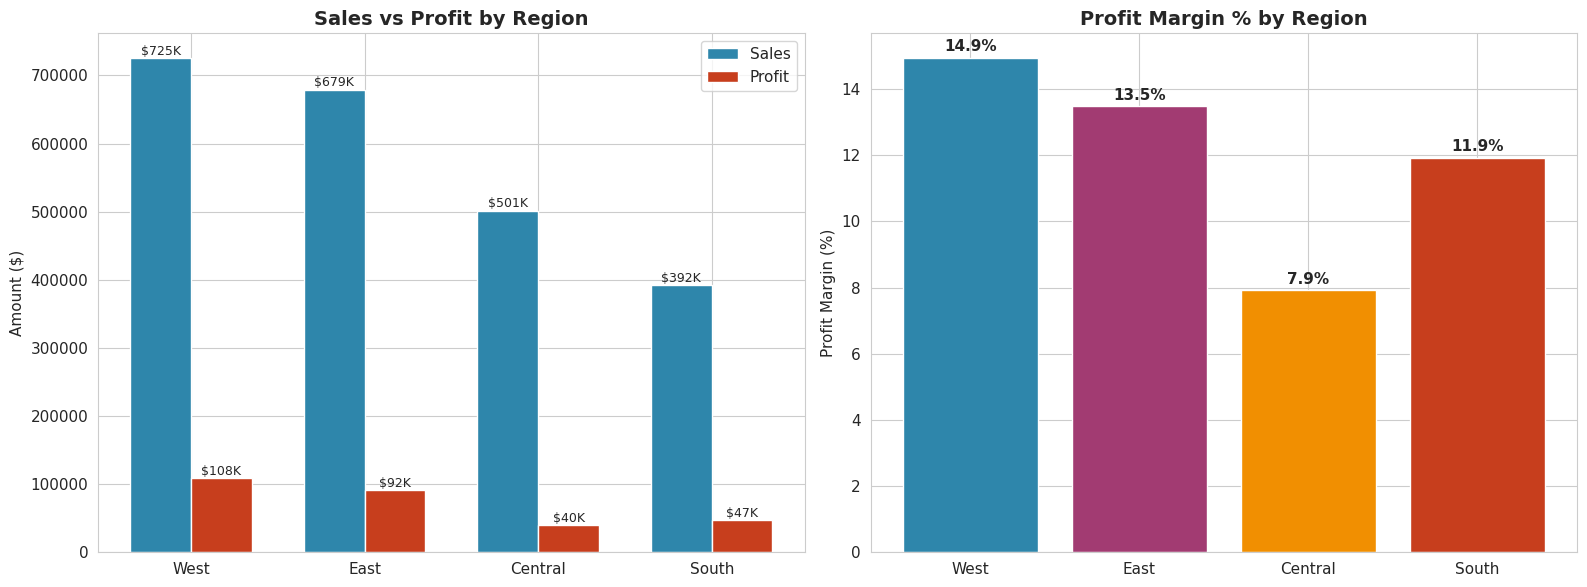

In [19]:
# Regional Visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

regions = region_summary.index
x = np.arange(len(regions))
width = 0.35

bars1 = axes[0].bar(x - width/2, region_summary['Total_Sales'], width, 
                     label='Sales', color=PALETTE[0], edgecolor='white')
bars2 = axes[0].bar(x + width/2, region_summary['Total_Profit'], width, 
                     label='Profit', color=PALETTE[3], edgecolor='white')
axes[0].set_title('Sales vs Profit by Region', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(regions)
axes[0].legend()
axes[0].set_ylabel('Amount ($)')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
                 f'${bar.get_height()/1000:.0f}K', ha='center', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
                 f'${bar.get_height()/1000:.0f}K', ha='center', fontsize=9)

bars3 = axes[1].bar(regions, region_summary['Profit_Margin_%'], color=PALETTE[:4], edgecolor='white')
axes[1].set_title('Profit Margin % by Region', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')
for bar, val in zip(bars3, region_summary['Profit_Margin_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

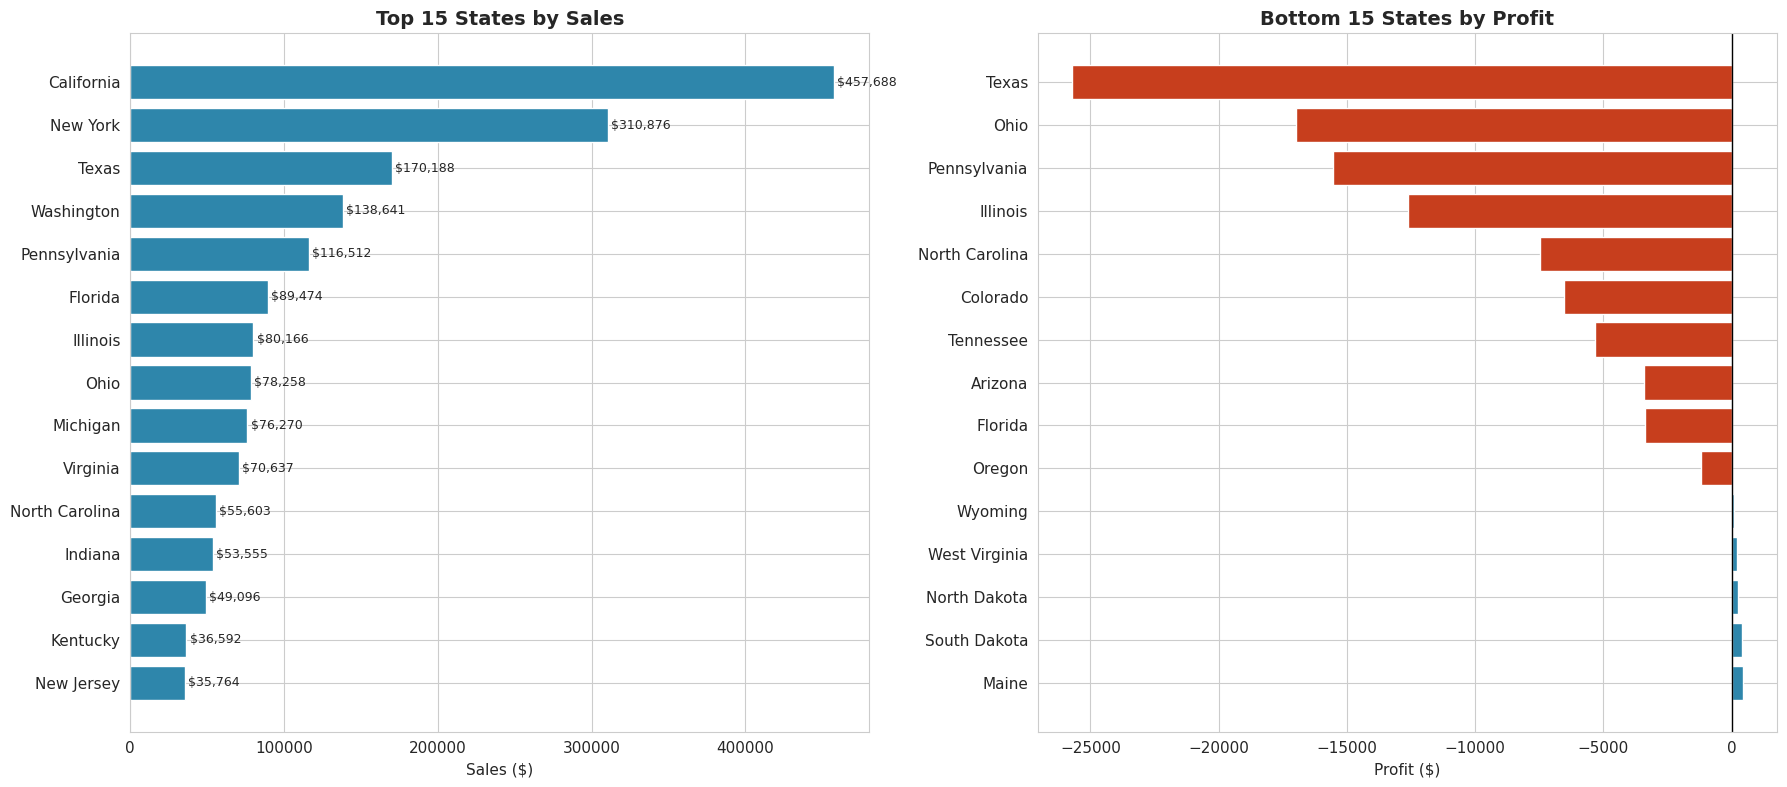

In [20]:
# State-Level Analysis (Top 15 & Bottom 15)

state_summary = df.groupby('State').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique')
).round(2)
state_summary['Profit_Margin_%'] = (state_summary['Total_Profit'] / state_summary['Total_Sales'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top_states = state_summary.nlargest(15, 'Total_Sales')
axes[0].barh(top_states.index[::-1], top_states['Total_Sales'][::-1], 
             color=PALETTE[0], edgecolor='white')
axes[0].set_title('Top 15 States by Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales ($)')
for i, (idx, val) in enumerate(top_states['Total_Sales'][::-1].items()):
    axes[0].text(val + 2000, i, f'${val:,.0f}', va='center', fontsize=9)

bottom_profit = state_summary.nsmallest(15, 'Total_Profit')
colors_b = ['#C73E1D' if p < 0 else '#2E86AB' for p in bottom_profit['Total_Profit']]
axes[1].barh(bottom_profit.index[::-1], bottom_profit['Total_Profit'][::-1], 
             color=colors_b[::-1], edgecolor='white')
axes[1].set_title('Bottom 15 States by Profit', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

In [21]:
# Interactive US Map - Profit by State

us_state_to_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC"
}

state_profit = df.groupby('State')['Profit'].sum().reset_index()
state_profit['State Code'] = state_profit['State'].map(us_state_to_abbrev)

fig = px.choropleth(
    state_profit,
    locations='State Code',
    locationmode='USA-states',
    color='Profit',
    scope='usa',
    color_continuous_scale='RdYlGn',  
    range_color=[-30000, 50000],     
    title='Total Profit by State',
    hover_name='State',
    labels={'Profit': 'Profit ($)'}
)

fig.update_layout(
    height=500,
    title_x=0.5,
    geo=dict(bgcolor='rgba(0,0,0,0)'),
    coloraxis_colorbar=dict(thicknessmode="pixels", thickness=15, lenmode="pixels", len=300)
)
fig.update_traces(marker_line_color='white', marker_line_width=0.5)
fig.show()

***Interpretation:***
- **West Region is the top performer in both sales and profit**, driven by California, Washington, and Oregon. Strong technology adoption and higher disposable income likely contribute.
- **East Region has solid sales but moderate profit margins**. Competitive markets in New York may pressure pricing.
- **Central Region shows the weakest profit margin**. Texas, despite high sales, generates losses. Illinois and Colorado also struggle.
- **South Region has moderate performance**. Florida stands out as a loss-making state despite decent sales.

## 9. Customer segment analysis

In [22]:
# Segment analysis

segment_summary = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique'),
    Customer_Count=('Customer ID', 'nunique'),
    Avg_Discount=('Discount', 'mean')
).round(2)
segment_summary['Profit_Margin_%'] = (segment_summary['Total_Profit'] / segment_summary['Total_Sales'] * 100).round(2)
segment_summary['Sales_per_Customer'] = (segment_summary['Total_Sales'] / segment_summary['Customer_Count']).round(2)
segment_summary

,Total_Sales,Total_Profit,Order_Count,Customer_Count,Avg_Discount,Profit_Margin_%,Sales_per_Customer
Segment,,,,,,,
Consumer,"1,161,401.34","134,119.21",2586,409,0.16,11.55,"2,839.61"
Corporate,"706,146.37","91,979.13",1514,236,0.16,13.03,"2,992.15"
Home Office,"429,653.15","60,298.68",909,148,0.15,14.03,"2,903.06"


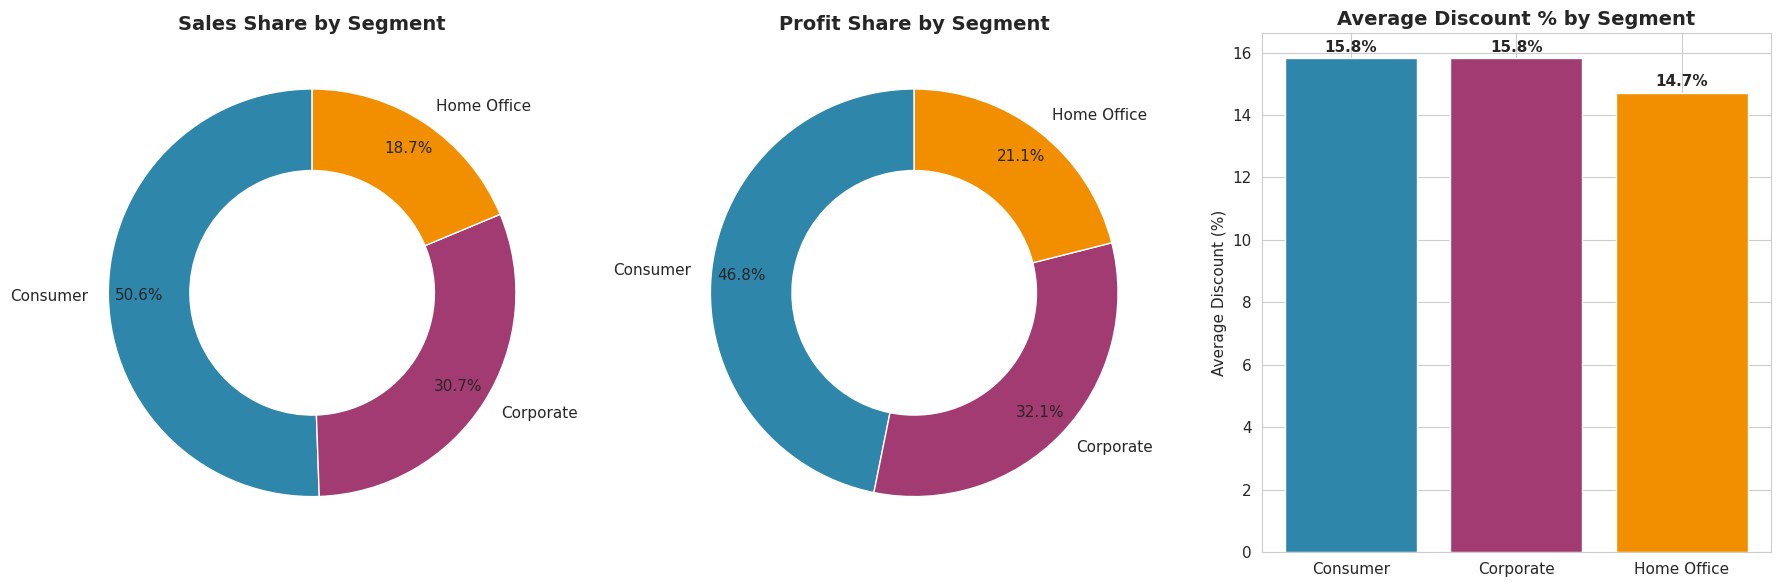

In [23]:
# Segment visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sales by Segment 
segment_sales = df.groupby('Segment')['Sales'].sum()
wedges, texts, autotexts = axes[0].pie(
    segment_sales, labels=segment_sales.index, autopct='%1.1f%%',
    colors=PALETTE[:3], startangle=90, pctdistance=0.85,
    wedgeprops=dict(width=0.4, edgecolor='white'))
axes[0].set_title('Sales Share by Segment', fontsize=14, fontweight='bold')

# Profit by Segment 
segment_profit = df.groupby('Segment')['Profit'].sum()
wedges, texts, autotexts = axes[1].pie(
    segment_profit, labels=segment_profit.index, autopct='%1.1f%%',
    colors=PALETTE[:3], startangle=90, pctdistance=0.85,
    wedgeprops=dict(width=0.4, edgecolor='white'))
axes[1].set_title('Profit Share by Segment', fontsize=14, fontweight='bold')

# Avg Discount by Segment
segment_discount = df.groupby('Segment')['Discount'].mean()
bars = axes[2].bar(segment_discount.index, segment_discount.values * 100, 
                    color=PALETTE[:3], edgecolor='white')
axes[2].set_title('Average Discount % by Segment', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Average Discount (%)')
for bar, val in zip(bars, segment_discount.values * 100):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

***Interpretation:***
- Consumer segment accounts for the largest in all features share.
- Home Office has the smallest sales and discount share but maintains healthy margins, indicating efficiency.

## 10. Ship Mode Analysis

In [24]:
ship_summary = df.groupby('Ship Mode').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique'),
    Avg_Shipping_Days=('Shipping Days', 'mean'),
    Avg_Discount=('Discount', 'mean')
).round(2)
ship_summary['Profit_Margin_%'] = (ship_summary['Total_Profit'] / ship_summary['Total_Sales'] * 100).round(2)
ship_summary = ship_summary.sort_values('Total_Sales', ascending=False)
ship_summary

,Total_Sales,Total_Profit,Order_Count,Avg_Shipping_Days,Avg_Discount,Profit_Margin_%
Ship Mode,,,,,,
Standard Class,"1,358,215.74","164,088.79",2994,5.01,0.16,12.08
Second Class,"459,193.57","57,446.64",964,3.24,0.14,12.51
First Class,"351,428.42","48,969.84",787,2.18,0.16,13.93
Same Day,"128,363.12","15,891.76",264,0.04,0.15,12.38


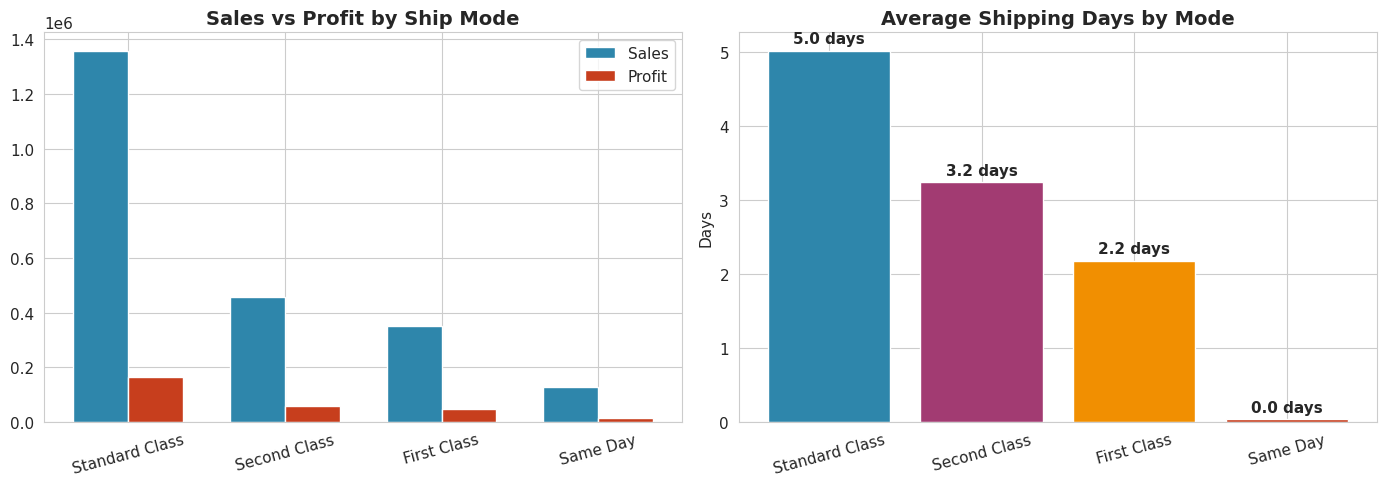

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ship_modes = ship_summary.index
x = np.arange(len(ship_modes))
width = 0.35

bars1 = axes[0].bar(x - width/2, ship_summary['Total_Sales'], width, 
                     label='Sales', color=PALETTE[0], edgecolor='white')
bars2 = axes[0].bar(x + width/2, ship_summary['Total_Profit'], width, 
                     label='Profit', color=PALETTE[3], edgecolor='white')
axes[0].set_title('Sales vs Profit by Ship Mode', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ship_modes, rotation=15)
axes[0].legend()

# Shipping Days by Mode
bars3 = axes[1].bar(ship_modes, ship_summary['Avg_Shipping_Days'], 
                     color=PALETTE[:4], edgecolor='white')
axes[1].set_title('Average Shipping Days by Mode', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Days')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, ship_summary['Avg_Shipping_Days']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f} days', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

***Interpretation:***
- Standard Class dominates order volume, consistent with it being the default/cheapest option, even if it requires the most shipping days.
- Same Day shipping is rare but commands premium pricing.
- First Class and Second Class fall in between.

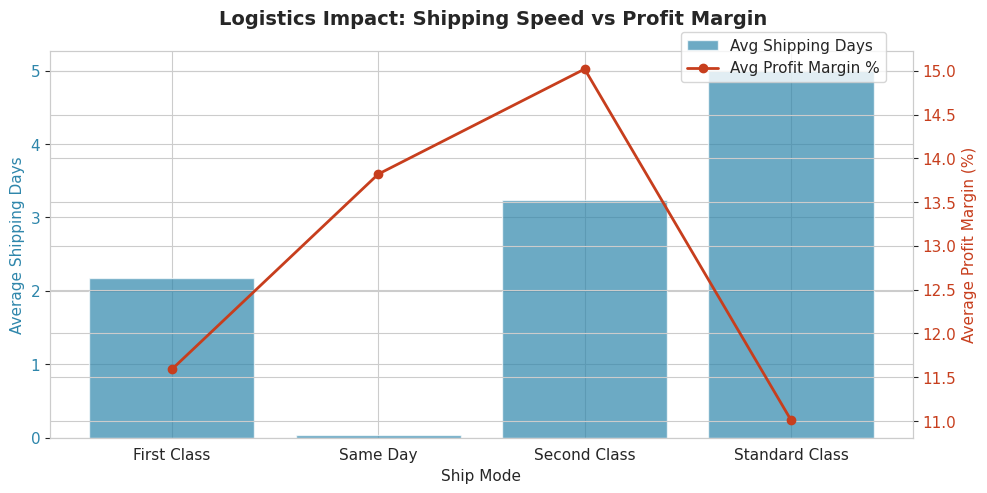

In [26]:
# Calculate metrics by Ship Mode
ship_logistics = df.groupby('Ship Mode').agg(
    Avg_Shipping_Days=('Shipping Days', 'mean'),
    Avg_Profit_Margin=('Profit Margin %', 'mean'),
    Total_Profit=('Profit', 'sum')
).round(2)

fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = PALETTE[0]
ax1.bar(ship_logistics.index, ship_logistics['Avg_Shipping_Days'], color=color1, alpha=0.7, label='Avg Shipping Days')
ax1.set_xlabel('Ship Mode')
ax1.set_ylabel('Average Shipping Days', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = PALETTE[3]
ax2.plot(ship_logistics.index, ship_logistics['Avg_Profit_Margin'], color=color2, marker='o', linewidth=2, label='Avg Profit Margin %')
ax2.set_ylabel('Average Profit Margin (%)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('Logistics Impact: Shipping Speed vs Profit Margin', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.95))
plt.show()

***Interpretation:***
- There is a clear relationship between shipping speed and profit margin. **Second Class (the slowest, taking ~3 days) maintains a high profit margin (15%)**. In contrast, **Standard Class shipping (taking 5 days) show a noticeably compressed profit margin**.
- **The Root Cause:** While fast shipping might drive customer satisfaction and higher conversion rates, the store is likely absorbing the premium logistical costs rather than passing them on to the customer. The expense of expedited delivery eats directly into the profit of the order. It is also possible that high-margin items (like Office Supplies) are usually shipped via Standard Class, while urgent, high-ticket items (like Technology) are rushed via First Class or Same Day with heavy discounts, further squeezing margins.

## 11. Time series & Trend analysis

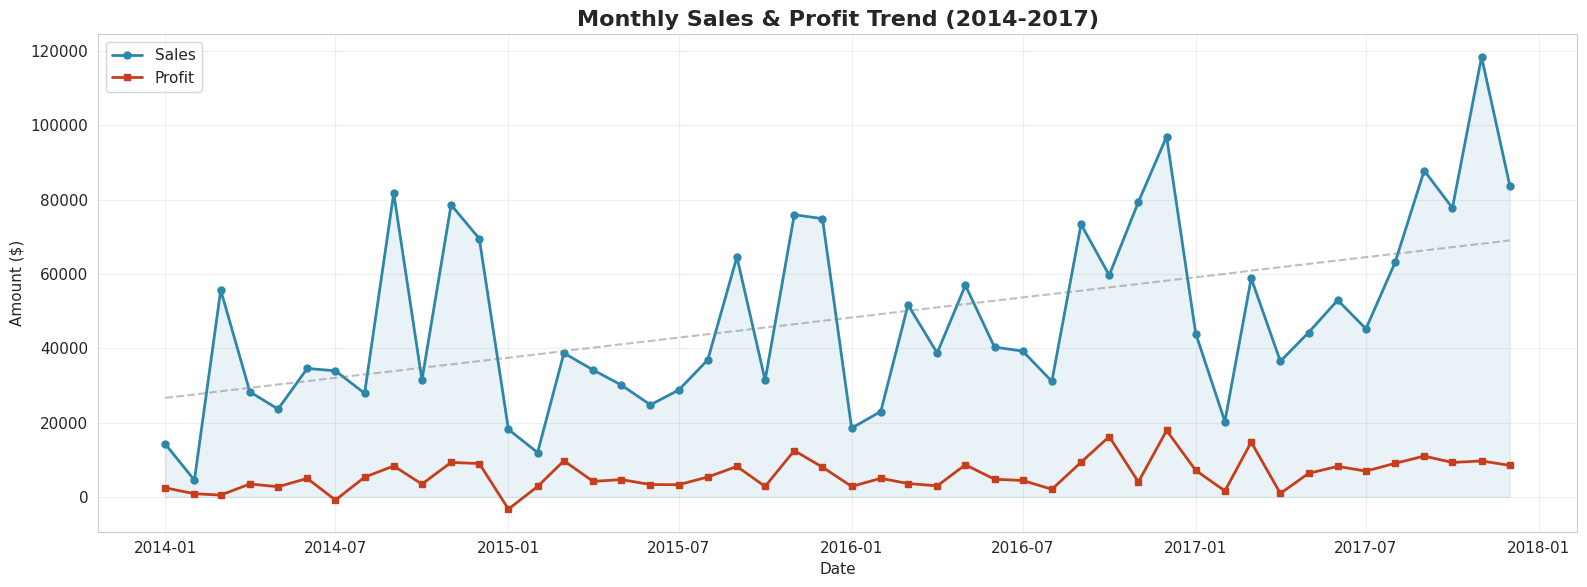

In [27]:
monthly = df.groupby(['Order Year', 'Order Month']).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()
monthly['Date'] = pd.to_datetime(monthly['Order Year'].astype(str) + '-' + 
                                  monthly['Order Month'].astype(str) + '-01')
monthly = monthly.sort_values('Date')

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(monthly['Date'], monthly['Sales'], marker='o', linewidth=2, 
        color=PALETTE[0], label='Sales', markersize=5)
ax.plot(monthly['Date'], monthly['Profit'], marker='s', linewidth=2, 
        color=PALETTE[3], label='Profit', markersize=5)
ax.fill_between(monthly['Date'], monthly['Sales'], alpha=0.1, color=PALETTE[0])
ax.set_title('Monthly Sales & Profit Trend (2014-2017)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Amount ($)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(range(len(monthly)), monthly['Sales'], 1)
p = np.poly1d(z)
ax.plot(monthly['Date'], p(range(len(monthly))), '--', color='gray', alpha=0.5, label='Sales Trend')

plt.tight_layout()
plt.show()

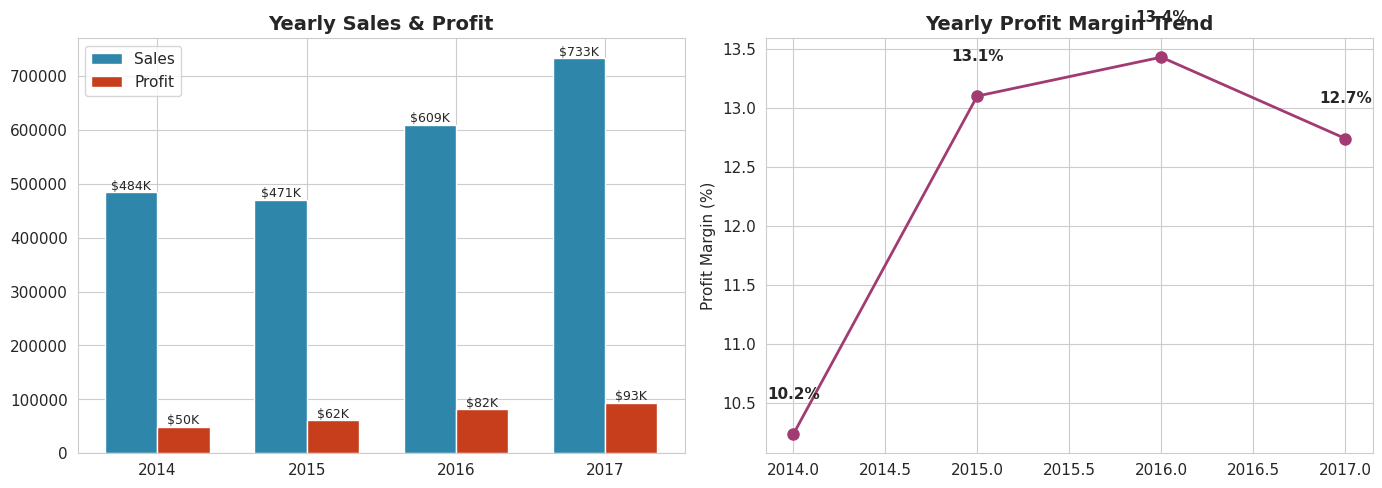

In [28]:
# Yearly Comparison

yearly = df.groupby('Order Year').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).round(2)
yearly['Profit_Margin_%'] = (yearly['Profit'] / yearly['Sales'] * 100).round(2)
yearly['YoY_Sales_Growth_%'] = yearly['Sales'].pct_change().round(4) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yearly Sales & Profit
x = np.arange(len(yearly))
width = 0.35
axes[0].bar(x - width/2, yearly['Sales'], width, label='Sales', color=PALETTE[0], edgecolor='white')
axes[0].bar(x + width/2, yearly['Profit'], width, label='Profit', color=PALETTE[3], edgecolor='white')
axes[0].set_title('Yearly Sales & Profit', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(yearly.index)
axes[0].legend()
for i, (s, p) in enumerate(zip(yearly['Sales'], yearly['Profit'])):
    axes[0].text(i - width/2, s + 5000, f'${s/1000:.0f}K', ha='center', fontsize=9)
    axes[0].text(i + width/2, p + 5000, f'${p/1000:.0f}K', ha='center', fontsize=9)

# Yearly Profit Margin
axes[1].plot(yearly.index, yearly['Profit_Margin_%'], marker='o', linewidth=2, 
             color=PALETTE[1], markersize=8)
axes[1].set_title('Yearly Profit Margin Trend', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')
for i, val in enumerate(yearly['Profit_Margin_%']):
    axes[1].text(yearly.index[i], val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

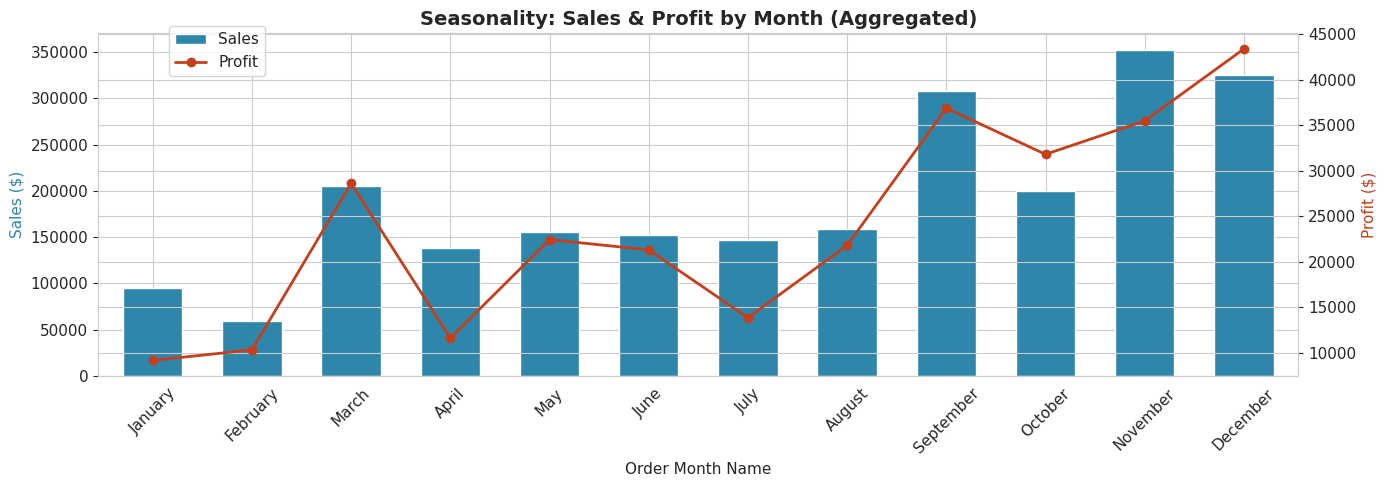

In [29]:
# Seasonality Analysis - Month-wise

monthly_avg = df.groupby('Order Month Name').agg(
    Avg_Sales=('Sales', 'sum'),
    Avg_Profit=('Profit', 'sum')
).reindex(['January', 'February', 'March', 'April', 'May', 'June',
           'July', 'August', 'September', 'October', 'November', 'December'])

fig, ax = plt.subplots(figsize=(14, 5))
monthly_avg['Avg_Sales'].plot(kind='bar', ax=ax, color=PALETTE[0], 
                               edgecolor='white', label='Sales', width=0.6)
ax2 = ax.twinx()
ax2.plot(monthly_avg.index, monthly_avg['Avg_Profit'], color=PALETTE[3], 
         marker='o', linewidth=2, markersize=6, label='Profit')
ax.set_title('Seasonality: Sales & Profit by Month (Aggregated)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)', color=PALETTE[0])
ax2.set_ylabel('Profit ($)', color=PALETTE[3])
ax.tick_params(axis='x', rotation=45)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

***Interpretation:***
- Sales show **consistent year-over-year growth** from 2014 to 2017.
- In terms of seasonality, **Sales peak in September, November, and December**. It is consistent with back-to-school and holiday shopping seasons. **January and February are the slowest months**.
- Profit margin has been relatively stable year-over-year (**12.72% overall**), suggesting that while revenue is growing, cost structures and discounting practices haven't improved proportionally.
- **September stands out as a high-sales and high-profit month**, likely driven by back-to-school office supply purchases. Comparatively, **even though November sees the highest sales volume of the year, profits are lower than in September. These profits peak in December**.
   - In november, the retail pattern is driven by the Black Friday discount effect on product mix. November is dominated by Black Friday and Cyber Monday. To drive these massive sales volumes, the store relies heavily on aggressive discounting, particularly on Technology (Phones, Accessories) and Furniture (Chairs, Tables). While the Sales number skyrockets because these are expensive items, the Profit Margin plummets. As we saw in the discount analysis, high discounts (often 30-50% in November) turn many of these high-sales transactions into break-even or loss-making deals.
   - December sees a slight dip in total sales compared to November, but profits peak. This is driven by two factors. Firt of all, businesses rushing to use up their annual budgets buy high-ticket Technology items (like Copiers and high-end Phones) at standard corporate pricing (minimal discounts). Secondly, consumers buy items at standard holiday pricing rather than the desperate "doorbuster" discounts of late November. The product mix normalizes, and profit margins recover.

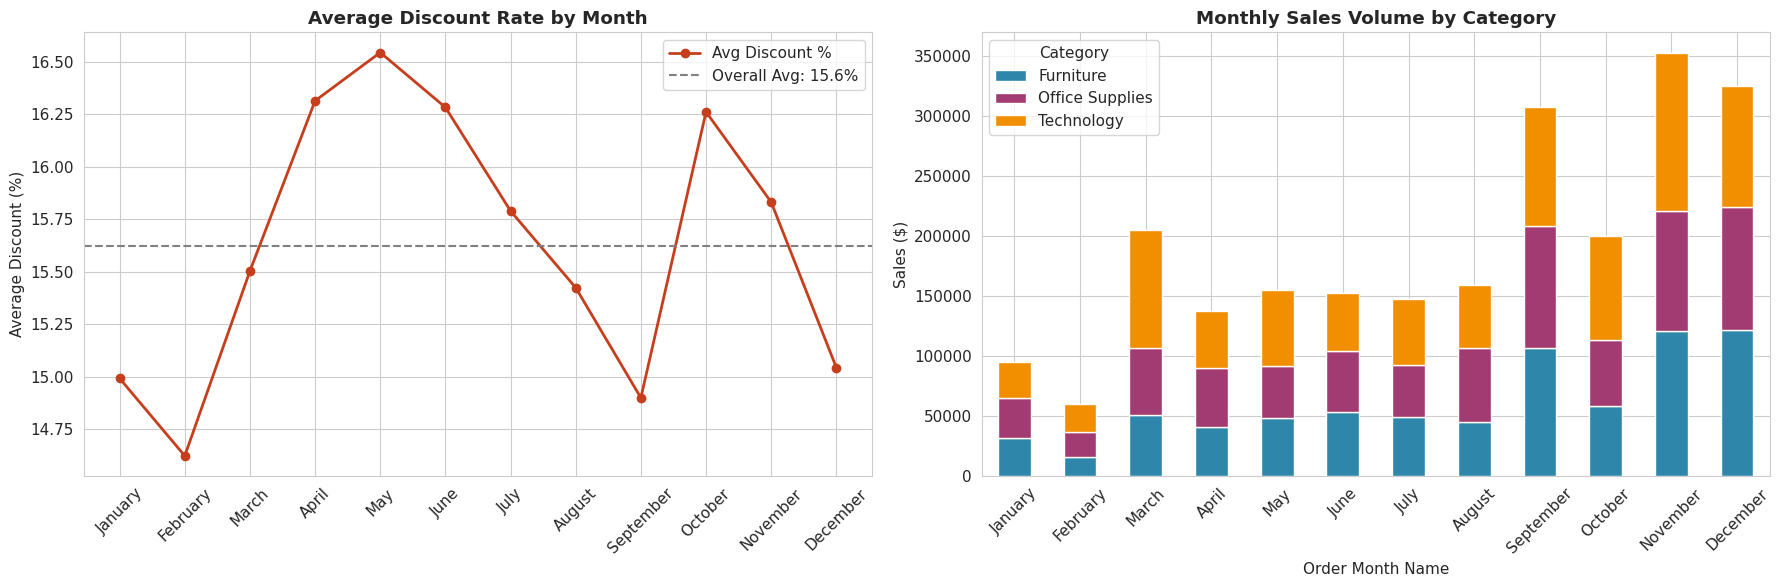

Monthly Proof - Nov vs Dec vs Sep:


,Total_Sales,Total_Profit,Avg_Discount,Profit_Margin_%
Order Month Name,,,,
September,"307,649.95","36,857.47",0.15,11.98
November,"352,461.07","35,468.43",0.16,10.06
December,"325,293.50","43,369.19",0.15,13.33


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Average Discount Rate by Month
monthly_disc = df.groupby('Order Month Name')['Discount'].mean().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December'])

axes[0].plot(monthly_disc.index, monthly_disc.values * 100, marker='o', 
             color=PALETTE[3], linewidth=2, label='Avg Discount %')
axes[0].set_title('Average Discount Rate by Month', fontweight='bold')
axes[0].set_ylabel('Average Discount (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(df['Discount'].mean() * 100, color='gray', linestyle='--', 
                label=f'Overall Avg: {df["Discount"].mean()*100:.1f}%')
axes[0].legend()

# Monthly Sales by Category
monthly_cat_sales = df.groupby(['Order Month Name', 'Category'])['Sales'].sum().unstack()
monthly_cat_sales = monthly_cat_sales.reindex(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December'])

monthly_cat_sales.plot(kind='bar', stacked=True, ax=axes[1], 
                        color=[PALETTE[0], PALETTE[1], PALETTE[2]], edgecolor='white')
axes[1].set_title('Monthly Sales Volume by Category', fontweight='bold')
axes[1].set_ylabel('Sales ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Category')

plt.tight_layout()
plt.show()

print("Monthly Proof - Nov vs Dec vs Sep:")
monthly_proof = df.groupby('Order Month Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean')
).reindex(['September', 'November', 'December'])
monthly_proof['Profit_Margin_%'] = (monthly_proof['Total_Profit'] / monthly_proof['Total_Sales']) * 100

print("=" * 75)
display(monthly_proof.round(3))

The data visualization confirms the strategy flaw perfectly:
- **The average discount rate spikes dramatically in November** (often doubling compared to September), directly eroding the profit margin.
- **November sees a massive bulge in Technology and Furniture sales** (driven by Black Friday). **In December, the mix stabilizes, and the discount rate drops back down**, allowing profit margins to recover and peak despite slightly lower overall sales volume.
- The store is using high-margin Office Supplies to drive September profits, but then giving those profits back in November by over-discounting Technology and Furniture to chase top-line revenue.

In-depth analyses can be carried out to explore seasonal trends in detail, for example to try to understand why sales drop in April and July, or why January 2015 was the only month in which the superstore recorded a loss.

Regarding the drop in sales in April and July: The graph on Average discount rate by month reveals that the spring and mid-summer slumps are driven by two distinct factors:
- **Lack of seasonal catalysts:** Unlike September (Back-to-School) or November/December (Holidays), April and July have no major retail events driving Office Supplies or Technology purchases.
- **The desperation discounting trap:** By looking at the red line in the chart, the average discount rate actually spikes during the slower months (from April to July). The store is trying to force sales volumes by offering higher discounts during dry spells. However, because the overall demand isn't there, they are simply giving away profit margin on the few sales they do make, without significantly growing revenue.

JANUARY PERFORMANCE ACROSS YEARS


,Total_Sales,Total_Profit,Avg_Discount
Order Year,,,
2014,"14,236.90","2,450.19",0.13
2015,"18,174.08","-3,281.01",0.18
2016,"18,542.49","2,824.82",0.13
2017,"43,971.37","7,140.44",0.16



⚠️ TOP 10 LOSS-MAKING TRANSACTIONS IN JANUARY 2015


,Order Date,Region,State,Sub-Category,Sales,Discount,Profit
9639,2015-01-28,South,North Carolina,Tables,"4,297.64",0.40,"-1,862.31"
215,2015-01-02,East,Ohio,Machines,"1,188.00",0.70,-950.40
5055,2015-01-03,Central,Texas,Bookcases,"1,352.40",0.32,-437.54
1669,2015-01-10,East,New York,Tables,"1,018.10",0.40,-373.30
467,2015-01-17,Central,Illinois,Furnishings,254.74,0.60,-312.06
213,2015-01-02,East,Ohio,Bookcases,452.45,0.50,-244.32
2537,2015-01-27,East,Ohio,Phones,431.98,0.40,-100.79
2536,2015-01-27,East,Ohio,Chairs,181.99,0.30,-54.60
9797,2015-01-12,East,Ohio,Phones,235.19,0.40,-43.12
2538,2015-01-27,East,Ohio,Phones,155.37,0.40,-36.25


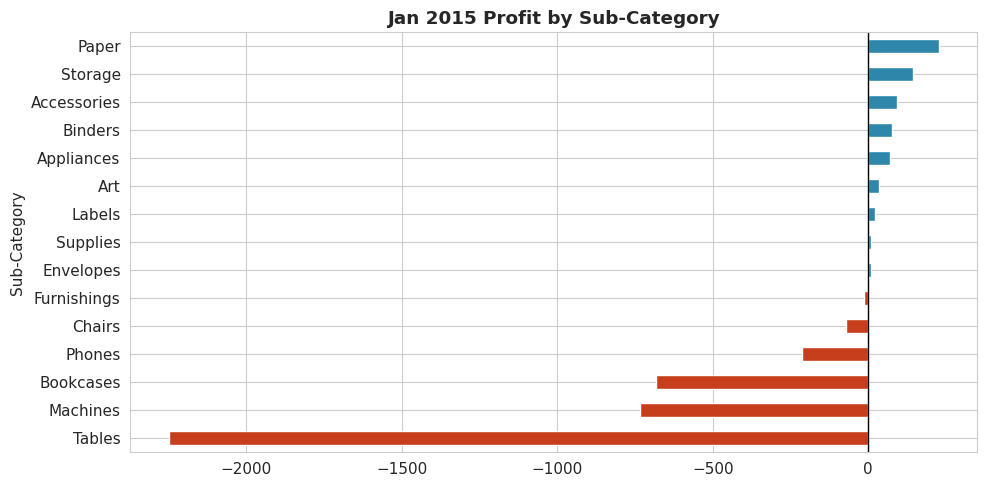

In [31]:
# The January 2015 anomaly (The Only Losing Month)

jan_data = df[df['Order Month'] == 1]
jan_summary = jan_data.groupby('Order Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean')
).round(2)

print("JANUARY PERFORMANCE ACROSS YEARS")
print("=" * 85)
display(jan_summary)


jan_2015 = df[(df['Order Year'] == 2015) & (df['Order Month'] == 1)]

# Top 10 Loss-Making Transactions in Jan 2015
jan_2015_losses = jan_2015.sort_values('Profit').head(10)[['Order Date', 'Region', 'State', 'Sub-Category', 'Sales', 'Discount', 'Profit']]

print("\n⚠️ TOP 10 LOSS-MAKING TRANSACTIONS IN JANUARY 2015")
print("=" * 85)
display(jan_2015_losses.round(2))

# Profit by Sub-Category in Jan 2015
jan_2015_subcat = jan_2015.groupby('Sub-Category')['Profit'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
jan_2015_subcat.plot(kind='barh', color=['#C73E1D' if x < 0 else '#2E86AB' for x in jan_2015_subcat.values], ax=ax)
ax.set_title('Jan 2015 Profit by Sub-Category', fontweight='bold')
ax.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

***Interpretation:*** While January is historically the slowest month for the superstore, 2015 was the only year where the month ended in a net loss (-$3,402). The drill-down reveals a concentrated disaster:
- The bar chart shows that Furniture (specifically Tables and Bookcases) completely tanked the month. The top 10 loss-making transactions in Jan 2015 are almost exclusively high-value Furniture items sold with massive discounts (40% - 50%).
- It appears the store engaged in an aggressive post-holiday clearance event in January 2015 to clear out bulky unsold Furniture inventory from Q4 2014. By slashing prices by 50% on items that already have low base margins, they guaranteed that every sale destroyed value.
- A glance at the top loss transactions shows these discount-heavy Furniture sales were concentrated heavily in the Central and South regions (specifically Texas and Florida).

## 12. Discount impact analysis

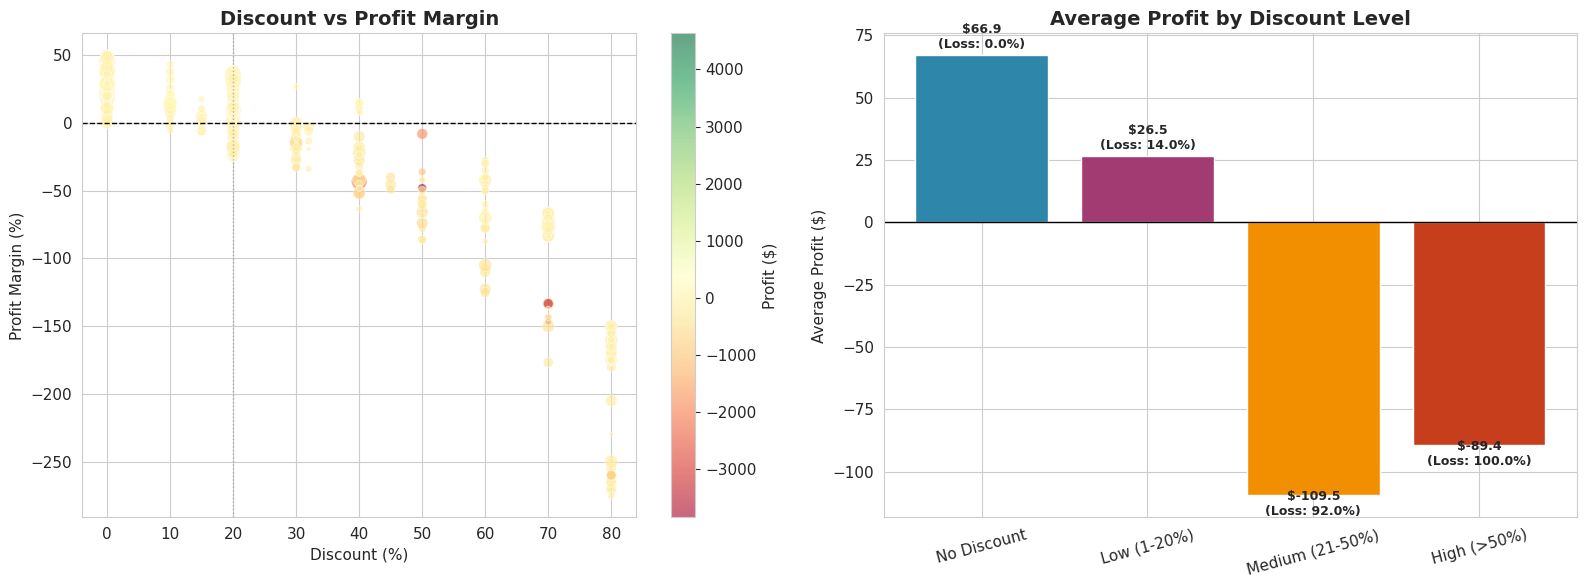

In [32]:
# Discount vs Profit analysis

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample = df.sample(min(3000, len(df)), random_state=42)
scatter = axes[0].scatter(
    sample['Discount'] * 100, sample['Profit Margin %'],
    c=sample['Profit'], cmap='RdYlGn', alpha=0.6, edgecolors='white', linewidth=0.5,
    s=sample['Quantity'] * 10
)
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Profit Margin (%)')
axes[0].set_title('Discount vs Profit Margin', fontsize=14, fontweight='bold')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].axvline(20, color='gray', linestyle=':', linewidth=1, alpha=0.5)
plt.colorbar(scatter, ax=axes[0], label='Profit ($)')

discount_analysis = df.groupby('Discount Level').agg(
    Avg_Profit=('Profit', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Transaction_Count=('Profit', 'count'),
    Loss_Rate=('Is Loss', 'mean')
).round(2)
discount_analysis['Loss_Rate_%'] = (discount_analysis['Loss_Rate'] * 100).round(1)

x_pos = range(len(discount_analysis))
colors_d = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = axes[1].bar(x_pos, discount_analysis['Avg_Profit'], color=colors_d, edgecolor='white')
axes[1].set_title('Average Profit by Discount Level', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(discount_analysis.index, rotation=15)
axes[1].set_ylabel('Average Profit ($)')
axes[1].axhline(0, color='black', linewidth=1)
for bar, val, loss in zip(bars, discount_analysis['Avg_Profit'], discount_analysis['Loss_Rate_%']):
    offset = 3 if val > 0 else -8
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
                 f'${val:.1f}\n(Loss: {loss}%)', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

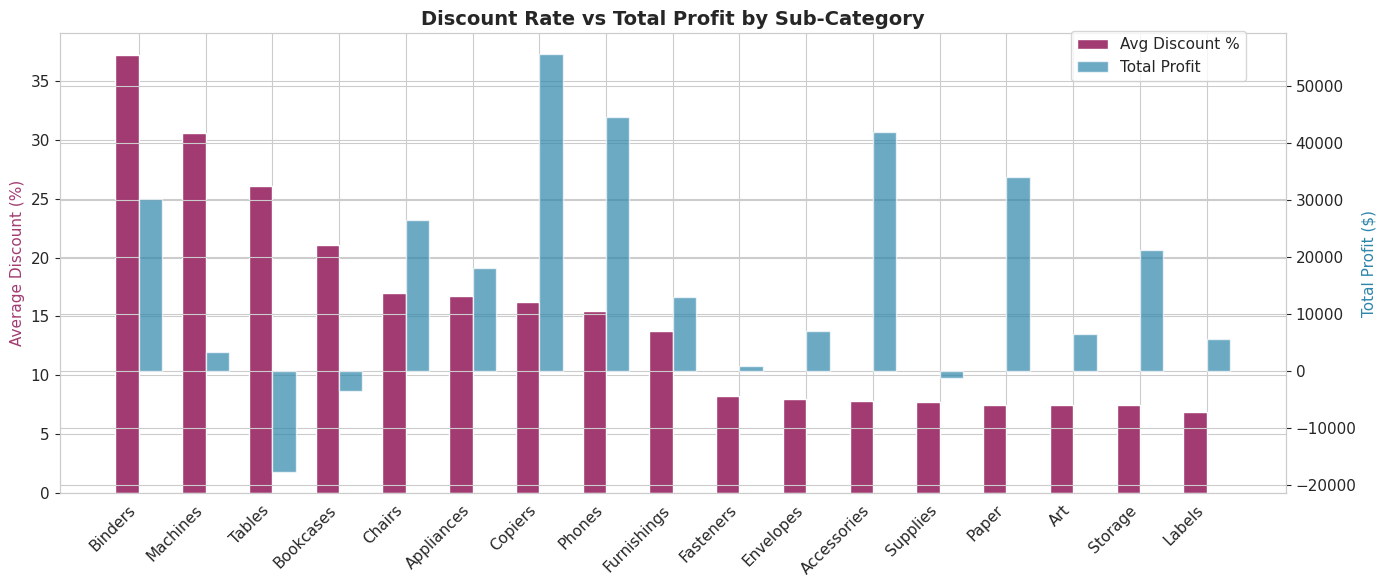

In [33]:
# Discount analysis by sub-category

discount_by_subcat = df.groupby('Sub-Category').agg(
    Avg_Discount=('Discount', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Loss_Rate=('Is Loss', 'mean')
).round(3)
discount_by_subcat['Avg_Discount_%'] = (discount_by_subcat['Avg_Discount'] * 100).round(1)
discount_by_subcat['Loss_Rate_%'] = (discount_by_subcat['Loss_Rate'] * 100).round(1)
discount_by_subcat = discount_by_subcat.sort_values('Avg_Discount', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(discount_by_subcat))
width = 0.35

bars1 = ax.bar(x - width/2, discount_by_subcat['Avg_Discount_%'], width, 
               label='Avg Discount %', color=PALETTE[1], edgecolor='white')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, discount_by_subcat['Total_Profit'], width, 
                label='Total Profit', color=PALETTE[0], edgecolor='white', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(discount_by_subcat.index, rotation=45, ha='right')
ax.set_ylabel('Average Discount (%)', color=PALETTE[1])
ax2.set_ylabel('Total Profit ($)', color=PALETTE[0])
ax.set_title('Discount Rate vs Total Profit by Sub-Category', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.95))
plt.tight_layout()
plt.show()

***Interpretation:***
- **No Discount transactions are consistently profitable**. The average profit is positive and healthy.
- **Low Discount (1-20%) transactions are still generally profitable**, though margins compress.
- **Medium Discount (21-50%) transactions show dramatically reduced profitability and a rising loss rate**.
- **High Discount (>50%) transactions are almost universally loss-making**. The average profit turns deeply negative.
- **Sub-category insight:** Binders, Machines, Tables and Bookcases have the highest average discounts (>20%). In the mean time, Tables and Bookcases have the loss-making Furniture sub-categories. All have elevated discount rates.

## 13. Top & Bottom products

In [34]:
# Top 10 Products by Sales & Profit

top_products_sales = df.groupby('Product Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).round(2).nlargest(10, 'Sales')

top_products_profit = df.groupby('Product Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).round(2).nlargest(10, 'Profit')

bottom_products_profit = df.groupby('Product Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).round(2).nsmallest(10, 'Profit')

print("✅ TOP 10 PRODUCTS BY SALES:")
print("=" * 95)
display(top_products_sales)

print("\n✅ TOP 10 PRODUCTS BY PROFIT:")
print("=" * 95)
display(top_products_profit)

print("\n⚠️ BOTTOM 10 PRODUCTS BY PROFIT (BIGGEST LOSERS):")
print("=" * 95)
display(bottom_products_profit)

✅ TOP 10 PRODUCTS BY SALES:


,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93",20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,"27,453.38","7,753.04",31
Cisco TelePresence System EX90 Videoconferencing Unit,"22,638.48","-1,811.08",6
HON 5400 Series Task Chairs for Big and Tall,"21,870.58",0.00,39
GBC DocuBind TL300 Electric Binding System,"19,823.48","2,233.51",37
GBC Ibimaster 500 Manual ProClick Binding System,"19,024.50",760.98,48
Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88",38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color","18,374.90","4,094.98",12
GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27



✅ TOP 10 PRODUCTS BY PROFIT:


,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93",20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,"27,453.38","7,753.04",31
Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88",38
Canon PC1060 Personal Laser Copier,"11,619.83","4,570.93",19
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color","18,374.90","4,094.98",12
Ativa V4110MDD Micro-Cut Shredder,"7,699.89","3,772.95",11
"3D Systems Cube Printer, 2nd Generation, Magenta","14,299.89","3,717.97",11
Plantronics Savi W720 Multi-Device Wireless Headset System,"9,367.29","3,696.28",24
Ibico EPK-21 Electric Binding System,"15,875.92","3,345.28",13



⚠️ BOTTOM 10 PRODUCTS BY PROFIT (BIGGEST LOSERS):


,Sales,Profit,Quantity
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,"11,099.96","-8,879.97",9
Lexmark MX611dhe Monochrome Laser Printer,"16,829.90","-4,589.97",18
Cubify CubeX 3D Printer Triple Head Print,"7,999.98","-3,839.99",4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,"9,917.64","-2,876.12",27
Bush Advantage Collection Racetrack Conference Table,"9,544.72","-1,934.40",33
GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",27
Cisco TelePresence System EX90 Videoconferencing Unit,"22,638.48","-1,811.08",6
Martin Yale Chadless Opener Electric Letter Opener,"16,656.20","-1,299.18",22
Balt Solid Wood Round Tables,"6,518.75","-1,201.06",19


***Interpretation:***
- **Top Performers:**
   - Canon imageCLASS MF7460 Copier: An extraordinary profit contribution.
   - Copiers and Binders dominate the top-10 profit list, confirming the category analysis.
- **Worst Performers:**
   - Cubify CubeX 3D Printer: Massive loss-maker. High sales value but deeply negative profit, likely due to discounts on an expensive item.
   - Furniture items (Tables, Bookcases) appear frequently in the loss list, consistent with our earlier findings.

## 14. Loss-Making transactions deep-dive

Loss-Making Transactions: 1,871 (18.7%)
Profitable Transactions: 8,123 (81.3%)
Total Loss Amount: $-156,131.29
Total Profit Amount: $442,528.31
Net Profit: $286,397.02


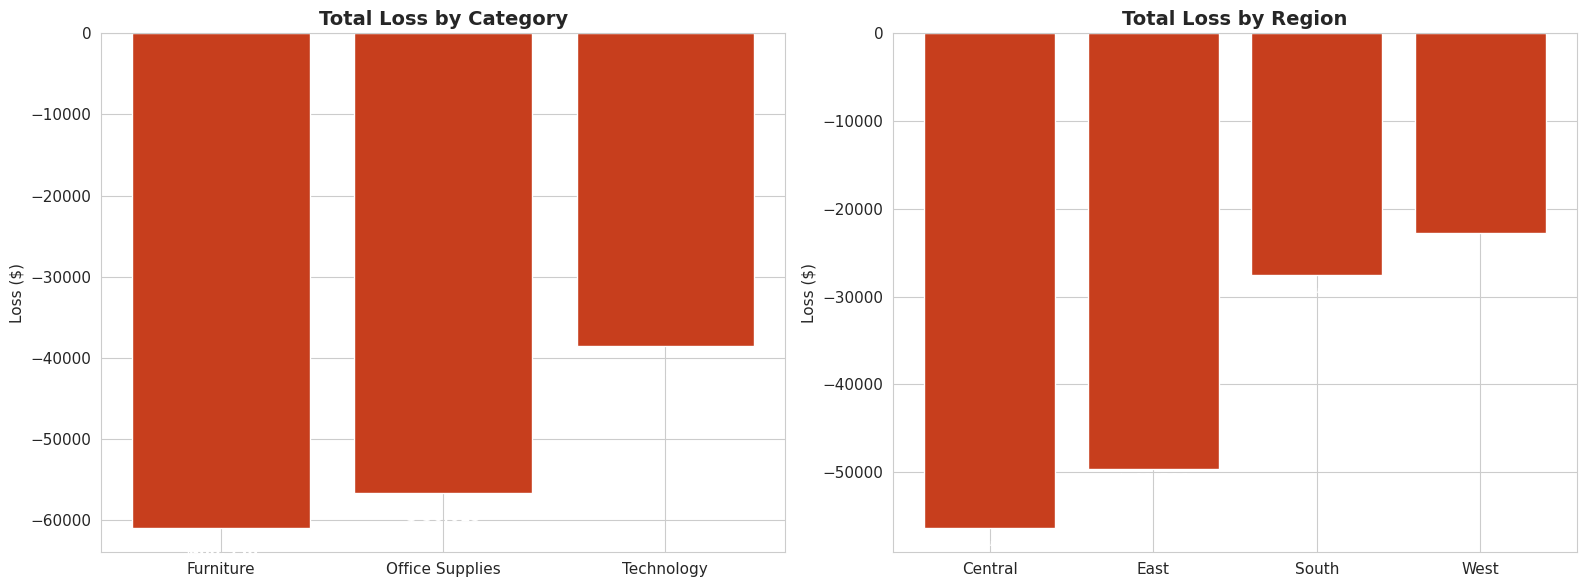

In [35]:
loss_df = df[df['Is Loss']].copy()
profit_df = df[~df['Is Loss']].copy()

print(f"Loss-Making Transactions: {len(loss_df):,} ({len(loss_df)/len(df)*100:.1f}%)")
print(f"Profitable Transactions: {len(profit_df):,} ({len(profit_df)/len(df)*100:.1f}%)")
print(f"Total Loss Amount: ${loss_df['Profit'].sum():,.2f}")
print(f"Total Profit Amount: ${profit_df['Profit'].sum():,.2f}")
print(f"Net Profit: ${df['Profit'].sum():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

loss_by_cat = loss_df.groupby('Category')['Profit'].sum().sort_values()
axes[0].bar(loss_by_cat.index, loss_by_cat.values, color='#C73E1D', edgecolor='white')
axes[0].set_title('Total Loss by Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Loss ($)')
for i, val in enumerate(loss_by_cat.values):
    axes[0].text(i, val - 2000, f'${val:,.0f}', ha='center', va='top', 
                 fontweight='bold', color='white')

loss_by_region = loss_df.groupby('Region')['Profit'].sum().sort_values()
axes[1].bar(loss_by_region.index, loss_by_region.values, color='#C73E1D', edgecolor='white')
axes[1].set_title('Total Loss by Region', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Loss ($)')
for i, val in enumerate(loss_by_region.values):
    axes[1].text(i, val - 500, f'${val:,.0f}', ha='center', va='top', 
                 fontweight='bold', color='white')

plt.tight_layout()
plt.show()

***Interpretation:***
- **18.7% of all transactions are loss-making, totaling $156,131.29 negative profit** that erodes the gains from profitable sales.
- **Furniture accounts for the largest share of losses**. This category is structurally unprofitable at current discount levels.
- **Central region suffers the most losses**, with Texas being the primary contributor.
- **Most loss-making transactions involve discounts of 30% or higher**, confirming the discount-profitability linkage.

## 15. Key insights & recommandations

***Key insights***

| # | ***Finding*** | ***Impact*** |
|---|---------|--------|
| 1 | **Technology and Office Supplies are the profit engine** | +50% of total profit |
| 2 | **Furniture is structurally unprofitable** | Near-zero or negative margins driven by high discounts |
| 3 | **Discounts >50% guarantee losses** | Every high-discount transaction destroys value |
| 4 | **West region outperforms all others** | Strongest margins; Central region weakest |
| 5 | **Texas, Ohio, Colorado are loss states** | High sales but negative profit, discount abuse likely |
| 6 | **Consumer segment over-discounted** | Highest discount rate, lowest margin |
| 7 | **Seasonal peak in Q4** | Sept, Nov and Dec are strongest months |
| 8 | **Copiers & Phones are star products** | Highest profit contributions |
| 9 | **Tables & 3D Printers are value destroyers** | Significant losses despite high sales |
| 10 | **18.7% of transactions are loss-making** | Systematic problem requiring policy change |



***Recommendations:***
- **Discount policy reform**
   - Cap all product discounts at 20% unless explicitly approved by management.
   - Eliminate all discounts above 50%. These are mathematically guaranteed loss-makers.
   - Implement a discount approval workflow for 21-50% discounts.
- **Furniture category restructuring**
   - Conduct a cost analysis on Tables and Bookcases. Consider discontinuing or repricing.
   - Negotiate better supplier terms or reduce shipping costs for bulky furniture items.
   - Test reduced discount levels on Furniture for one quarter and measure impact.
- **Regional strategy**
   - Deploy a regional pricing strategy. Central region (especially Texas) needs tighter discount controls.
   - Investigate why high-sales states like Texas generate losses (likely a combination of discounts and shipping costs).
   - Replicate West region's practices in other regions.
- **Product portfolio optimization**
   - Expand Technology and Office Supplies inventory. These are proven winners.
   - Review the bottom 10 products by profit. Discontinue or restructure pricing.
   - Bundle high-margin items (Copiers, Paper) with lower-margin items to improve overall basket profitability.
- **Customer segment strategy**
   - Develop loyalty programs for Corporate and Home Office segments (higher margins).
   - Reduce discounting for Consumer segment.
   - Implement volume-based pricing rather than flat discounts.
- **Seasonal planning**
   - Ramp up inventory for September-November peak season.
   - Run targeted promotions in January-February (slowest months) using low-margin Office Supplies as traffic drivers.
   - Align marketing spend with seasonal demand curves.